In [1]:
import yaml
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from collections import defaultdict
import seaborn
%matplotlib inline


In [46]:

C_DET   = '#2ECC71'   # detected
C_BEL   = '#E74C3C'   # below threshold
C_NOB   = '#F39C12'   # no blobs
C_IDX2  = '#3498DB'   # spectral index 2
C_IDX3  = '#E67E22'   # spectral index 3
BG      = '#0D1117'
FG      = '#E8EDF3'
GRID    = '#1E2733'
SPINE   = '#2C3E50'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    SPINE,
    'axes.labelcolor':   FG,
    'axes.titlecolor':   FG,
    'text.color':        FG,
    'xtick.color':       FG,
    'ytick.color':       FG,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'font.family':       'monospace',
    'axes.titlesize':    11,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'legend.facecolor':  SPINE,
    'legend.edgecolor':  GRID,
})

MATCH_RADIUS_DEG = 0.2   


def _make_record(fname: str, v: dict) -> dict:
    """Build a normalised record dict from a raw YAML entry."""
    ps_kept  = v.get('ps_kept')  or []
    ext_kept = v.get('ext_kept') or []
    return {
        'filename':         fname,
        'source_type':      v.get('source_type'),
        'true_extension':   v.get('true_extension'),
        'flux_fraction':    v.get('flux_fraction'),
        'spectral_index':   v.get('spectral_index'),
        'status':           v.get('status'),
        'max_significance': v.get('max_significance'),
        'n_detected':       len(ps_kept) + len(ext_kept),
        'ps_kept':          ps_kept,
        'ext_kept':         ext_kept,
    }

def angular_sep(ra1, dec1, ra2, dec2):
    """Great-circle separation in degrees."""
    ra1, dec1, ra2, dec2 = map(np.radians, [ra1, dec1, ra2, dec2])
    return np.degrees(np.arccos(np.clip(
        np.sin(dec1)*np.sin(dec2) + np.cos(dec1)*np.cos(dec2)*np.cos(ra1 - ra2),
        -1, 1
    )))

# def classify_detections(records, true_ra, true_dec, match_radius=MATCH_RADIUS_DEG):
#     """
#     For each file classify its detected blobs as TP or FP, and the file
#     itself as TP / FP / FN / TN.

#     A blob is a True Positive  if its (ra, dec) is within match_radius of
#     the true source position.
#     A blob is a False Positive if it is detected but outside match_radius.

#     File-level outcome
#     ------------------
#     TP  : file has ≥1 detected blob within match_radius
#     FP  : file has detections but none within match_radius
#     FN  : file has max_significance ≥ 5σ but zero blobs detected
#     TN  : file is genuinely below threshold (max_sig < 5σ)
#     """
#     tp_files, fp_files, fn_files, tn_files = [], [], [], []
#     tp_blobs, fp_blobs = [], []

#     for r in records:
#         all_blobs_in_file = r['ps_kept'] + r['ext_kept']

#         # Annotate each blob with its match status
#         matched_in_file = []
#         for b in all_blobs_in_file:
#             ra  = b.get('ra',  b.get('l_deg'))
#             dec = b.get('dec', b.get('b_deg'))
#             if ra is None or dec is None:
#                 continue
#             sep = angular_sep(ra, dec, true_ra, true_dec)
#             b_ann = {
#                 **b,
#                 'flux_fraction':  r['flux_fraction'],
#                 'true_extension': r['true_extension'],
#                 'spectral_index': r['spectral_index'],
#                 'sep_deg':        sep,
#                 'match':          sep <= match_radius,
#             }
#             if sep <= match_radius:
#                 tp_blobs.append(b_ann)
#                 matched_in_file.append(b_ann)
#             else:
#                 fp_blobs.append(b_ann)

#         # File-level verdict
#         sig = r.get('max_significance') or 0
#         if matched_in_file:
#             tp_files.append(r)
#         elif all_blobs_in_file:
#             fp_files.append(r)           # blobs found, but none near true pos
#         elif sig >= 5.0:
#             fn_files.append(r)           # significant map but missed source
#         else:
#             tn_files.append(r)           # genuinely below threshold

#     return tp_files, fp_files, fn_files, tn_files, tp_blobs, fp_blobs
def classify_detections(
    records: list[dict],
    true_ra: float,
    true_dec: float,
    match_radius: float = MATCH_RADIUS_DEG,
) -> tuple[list, list, list, list, list, list]:
    """
    File-level classification — all 6 combinations:

    ≥5σ cases:
      TP        : ≥5σ, exactly 1 blob, within match_radius
      FP_multi  : ≥5σ, >1 blob detected (regardless of position)
      FP_wrong  : ≥5σ, exactly 1 blob, outside match_radius
      FN        : ≥5σ, 0 blobs detected

    <5σ cases:
      TN_clean  : <5σ, 0 blobs detected           (truly quiet)
      TN_ghost  : <5σ, ≥1 blob detected            (spurious, sub-threshold)
    """
    tp_files      = []   # ≥5σ, 1 blob, matched
    fp_multi_files = []  # ≥5σ, >1 blob
    fp_wrong_files = []  # ≥5σ, 1 blob, unmatched
    fn_files      = []   # ≥5σ, 0 blobs
    tn_clean_files = []  # <5σ, 0 blobs
    tn_ghost_files = []  # <5σ, ≥1 blob (spurious)
    tp_blobs, fp_blobs = [], []

    for r in records:
        all_blobs = r['ps_kept'] + r['ext_kept']
        sig       = r.get('max_significance') or 0.0

        # ── annotate every blob with its separation ───────────────────────
        annotated = []
        for b in all_blobs:
            ra  = b.get('ra',  b.get('l_deg'))
            dec = b.get('dec', b.get('b_deg'))
            if ra is None or dec is None:
                continue
            sep = angular_sep(ra, dec, true_ra, true_dec)
            annotated.append({
                **b,
                'flux_fraction':  r['flux_fraction'],
                'true_extension': r['true_extension'],
                'spectral_index': r['spectral_index'],
                'sep_deg':        sep,
                'match':          False,
            })

        n_det      = len(annotated)
        candidates = [b for b in annotated if b['sep_deg'] <= match_radius]
        best_match = min(candidates, key=lambda b: b['sep_deg']) if candidates else None

        # ── blob-level bookkeeping ────────────────────────────────────────
        for b in annotated:
            if best_match is not None and b is best_match:
                b['match'] = True
                tp_blobs.append(b)
            else:
                fp_blobs.append(b)

        # ── file-level verdict (all 6 bins) ───────────────────────────────
        if sig >= 5.0:
            if n_det == 0:
                fn_files.append(r)            # ≥5σ · 0 blobs
            elif n_det == 1 and best_match:
                tp_files.append(r)            # ≥5σ · 1 blob · matched
            elif n_det == 1 and not best_match:
                fp_wrong_files.append(r)      # ≥5σ · 1 blob · wrong position
            else:
                fp_multi_files.append(r)      # ≥5σ · >1 blob
        else:
            if n_det == 0:
                tn_clean_files.append(r)      # <5σ · 0 blobs  (ideal TN)
            else:
                tn_ghost_files.append(r)      # <5σ · ≥1 blob  (ghost/spurious)

    return (tp_files, fp_multi_files, fp_wrong_files, fn_files,
            tn_clean_files, tn_ghost_files,
            tp_blobs, fp_blobs)

def plot_blob_offsets(blobs, true_ra, true_dec,  extension=0.25):
    fig = plt.figure(figsize=(16, 10))
    fig.patch.set_facecolor(BG)

    # ---- filter blobs ----
    blobs_2 = [b for b in blobs if b['spectral_index'] == 2.0]
    blobs_3 = [b for b in blobs if b['spectral_index'] == 3.0]

    # ---- arrays ----
    ra_offset_2 = [true_ra - b['ra'] for b in blobs_2]
    dec_offset_2 = [true_dec - b['dec'] for b in blobs_2]
    ra_vals_2 = [b['ra'] for b in blobs_2]
    dec_vals_2 = [b['dec'] for b in blobs_2]
    flux_2 = [b['flux_fraction'] for b in blobs_2]

    ra_offset_3 = [true_ra - b['ra'] for b in blobs_3]
    dec_offset_3 = [true_dec - b['dec'] for b in blobs_3]
    ra_vals_3 = [b['ra'] for b in blobs_3]
    dec_vals_3 = [b['dec'] for b in blobs_3]
    flux_3 = [b['flux_fraction'] for b in blobs_3]

    # ---------- panel 1 ----------
    ax = fig.add_subplot(221)
    sc = ax.scatter(ra_offset_2, dec_vals_2, s=50, c=flux_2, cmap='plasma', marker='x')
    fig.colorbar(sc, ax=ax).set_label("Crab Flux Fraction", fontsize=14)

    ax.axvline(0.0, color='white', lw=1.8)
    ax.axvline(0.1, color=C_IDX2, lw=1.4, ls='--')
    ax.axvline(-0.1, color=C_IDX2, lw=1.4, ls='--')

    ax.set_xlabel('RA Offset (true-detected) [deg]', fontsize=12)
    ax.set_ylabel('True Dec [deg]', fontsize=12)
    ax.set_ylim(true_dec-2, true_dec+2)
    ax.tick_params(labelsize=14)
    ax.grid(ls=':', alpha=0.6)


    # ---------- panel 2 ----------
    ax2 = fig.add_subplot(222)
    sc = ax2.scatter(ra_vals_2, dec_offset_2, s=50, c=flux_2, cmap='plasma', marker='x')
    fig.colorbar(sc, ax=ax2).set_label("Crab Flux Fraction", fontsize=14)

    ax2.axhline(0.0, color='white', lw=1.8)
    ax2.axhline(0.1, color=C_IDX2, lw=1.4, ls='--')
    ax2.axhline(-0.1, color=C_IDX2, lw=1.4, ls='--')

    ax2.set_xlabel('True RA [deg]', fontsize=12)
    ax2.set_ylabel('Dec Offset (true-detected) [deg]', fontsize=12)
    ax2.set_xlim(true_ra-2, true_ra+2)
    ax2.tick_params(labelsize=14)
    ax2.grid(ls=':', alpha=0.6)


    # ---------- panel 3 ----------
    ax3 = fig.add_subplot(223)
    sc = ax3.scatter(ra_offset_3, dec_vals_3, s=50, c=flux_3, cmap='plasma', marker='x')
    fig.colorbar(sc, ax=ax3).set_label("Crab Flux Fraction", fontsize=14)

    ax3.axvline(0.0, color='white', lw=1.8)
    ax3.axvline(0.1, color=C_IDX2, lw=1.4, ls='--')
    ax3.axvline(-0.1, color=C_IDX2, lw=1.4, ls='--')

    ax3.set_xlabel('RA Offset (true-detected) [deg]', fontsize=12)
    ax3.set_ylabel('True Dec [deg]', fontsize=12)
    ax3.set_ylim(true_dec-2, true_dec+2)
    ax3.tick_params(labelsize=14)
    ax3.grid(ls=':', alpha=0.6)


    # ---------- panel 4 ----------
    ax4 = fig.add_subplot(224)
    sc = ax4.scatter(ra_vals_3, dec_offset_3, s=50, c=flux_3, cmap='plasma', marker='x')
    fig.colorbar(sc, ax=ax4).set_label("Crab Flux Fraction", fontsize=14)

    ax4.axhline(0.0, color='white', lw=1.8)
    ax4.axhline(0.1, color=C_IDX2, lw=1.4, ls='--')
    ax4.axhline(-0.1, color=C_IDX2, lw=1.4, ls='--')

    ax4.set_xlabel('True RA [deg]', fontsize=12)
    ax4.set_ylabel('Dec Offset (true-detected) [deg]', fontsize=12)
    ax4.set_xlim(true_ra-2, true_ra+2)
    ax4.tick_params(labelsize=14)
    ax4.grid(ls=':', alpha=0.6)
    fig.suptitle(f"Crab Sim {extension} degree", fontsize=20, y=1.02)
    fig.text(0.5, 0.97, r"Spectral Index $\gamma = 2.0$",
            ha='center', fontsize=18)

    fig.text(0.5, 0.48, r"Spectral Index $\gamma = 3.0$",
            ha='center', fontsize=18)
    fig.tight_layout()
    plt.show()

def blob_characteristics(records):
    det   = [r for r in records if r['status'] == 'detected']
    below = [r for r in records if r['status'] == 'below_threshold']
    nob   = [r for r in records if r['status'] == 'no_blobs']
    idx2  = [r for r in records if r['spectral_index'] == 2.0]
    idx3  = [r for r in records if r['spectral_index'] == 3.0]
    all_ff = sorted(set(r['flux_fraction'] for r in records if r['flux_fraction'] is not None))

    blobs = []
    for r in det:
        for b in (r['ps_kept'] + r['ext_kept']):
            blobs.append({
                **b,
                'flux_fraction':  r['flux_fraction'],
                'true_extension': r['true_extension'],
                'spectral_index': r['spectral_index'],
                'ra':             b.get('ra',  b.get('l_deg')),
                'dec':            b.get('dec', b.get('b_deg')),
                'circle_radius':  b.get('circle_radius',  b.get('radius_deg')),
                'sigma_radius':   b.get('sigma_radius',   b.get('radius_deg')),
            })


    print(f"Total records for : {len(records)}")
    print(f"  Detected    : {len(det)}")
    print(f"  Below 5σ    : {len(below)}")
    print(f"  No blobs    : {len(nob)}")
    print(f"  Total blobs : {len(blobs)}  "
        f"(PS: {sum(len(r['ps_kept']) for r in det)}  "
        f"EXT: {sum(len(r['ext_kept']) for r in det)})")
    return blobs, all_ff


In [ ]:
YAML_PATH = '/lustre/hawcz01/scratch/userspace/rbabu/astroimage/AstroImageDetection/new_results/blob_detection_kept.yaml'

with open(YAML_PATH) as f:
    raw = yaml.safe_load(f)

true_ra  = 83.61
true_dec = 22.0

records0p25 = []
records0p5 = []
records0p75 = []
records1p0 = []
EXTENSION_BINS = [0.01, 0.25, 0.5, 0.75, 1.0]

records_by_ext: dict[float, list[dict]] = {e: [] for e in EXTENSION_BINS}

for fname, v in raw.items():
    ext = v.get('true_extension')
    if ext in records_by_ext:
        records_by_ext[ext].append(_make_record(fname, v))

records0p01 = records_by_ext[0.01]
records0p25 = records_by_ext[0.25]
records0p5 = records_by_ext[0.5]
records0p75 = records_by_ext[0.75]
records1p0  = records_by_ext[1.0]


In [72]:
blobs0p01, allff0p01 = blob_characteristics(records0p01)
blobs0p25, allff0p25 = blob_characteristics(records0p25)
blobs0p5, allff0p5 = blob_characteristics(records0p5)
blobs0p75, allff0p75 = blob_characteristics(records0p75)
blobs1p0, allff1p0 = blob_characteristics(records1p0)

Total records for : 58
  Detected    : 47
  Below 5σ    : 11
  No blobs    : 0
  Total blobs : 47  (PS: 17  EXT: 30)
Total records for : 44
  Detected    : 37
  Below 5σ    : 7
  No blobs    : 0
  Total blobs : 38  (PS: 14  EXT: 24)
Total records for : 44
  Detected    : 34
  Below 5σ    : 10
  No blobs    : 0
  Total blobs : 47  (PS: 25  EXT: 22)
Total records for : 44
  Detected    : 25
  Below 5σ    : 19
  No blobs    : 0
  Total blobs : 49  (PS: 32  EXT: 17)
Total records for : 44
  Detected    : 18
  Below 5σ    : 26
  No blobs    : 0
  Total blobs : 55  (PS: 42  EXT: 13)


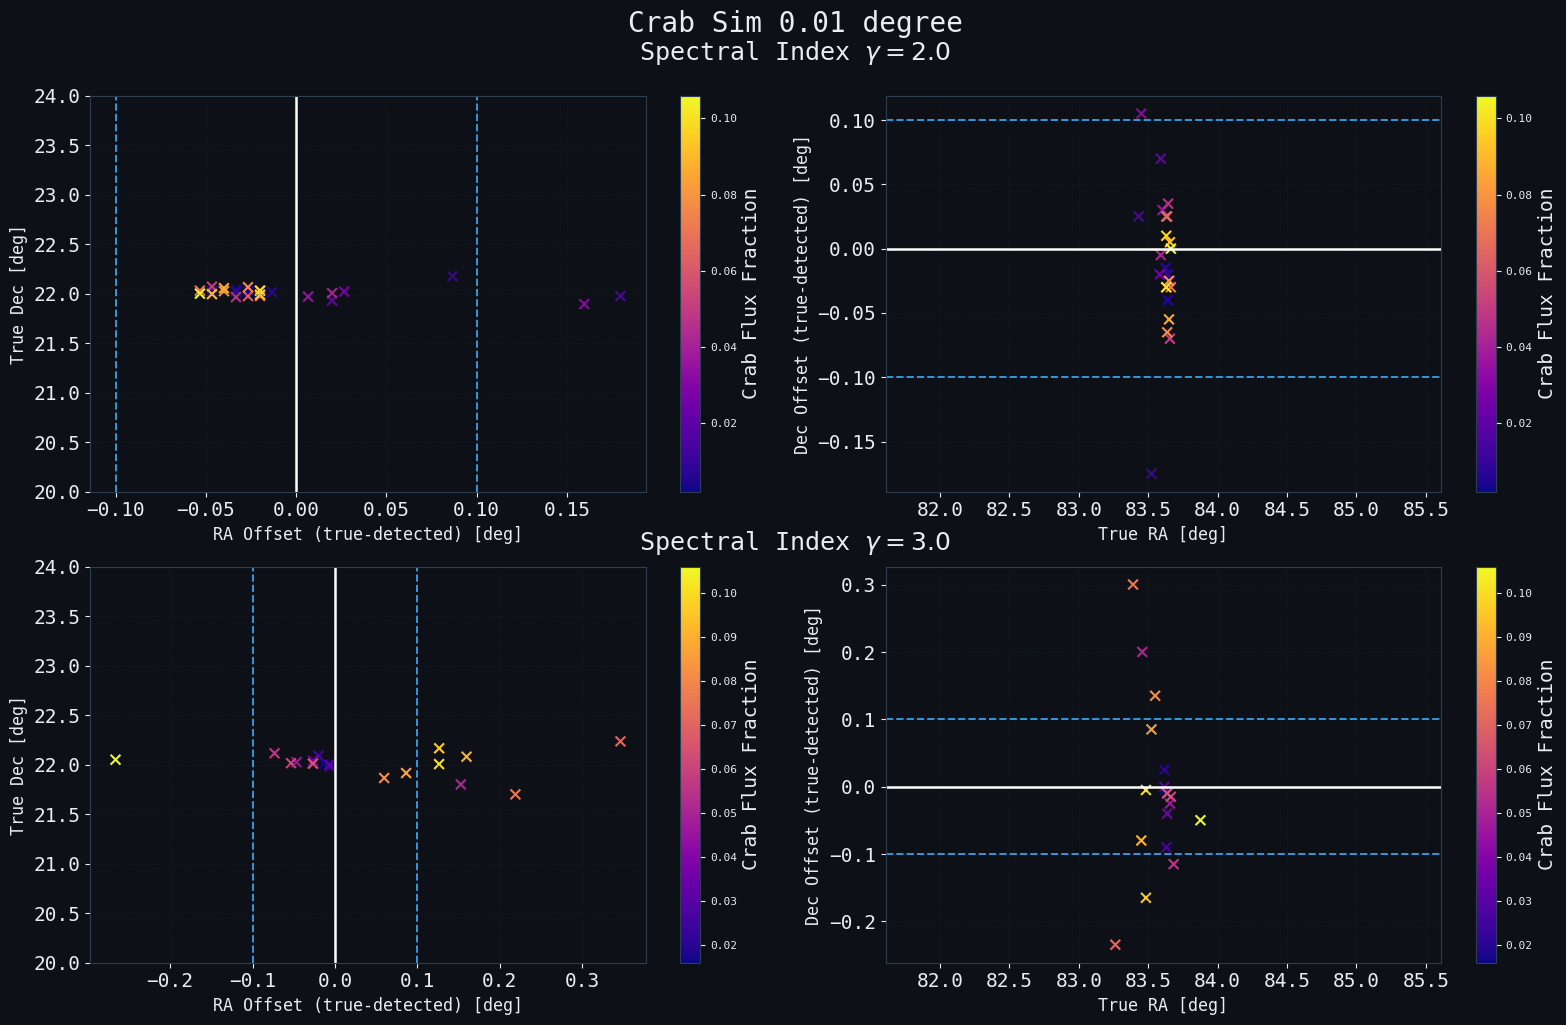

In [73]:
plot_blob_offsets(blobs0p01, true_ra, true_dec, extension=0.01)

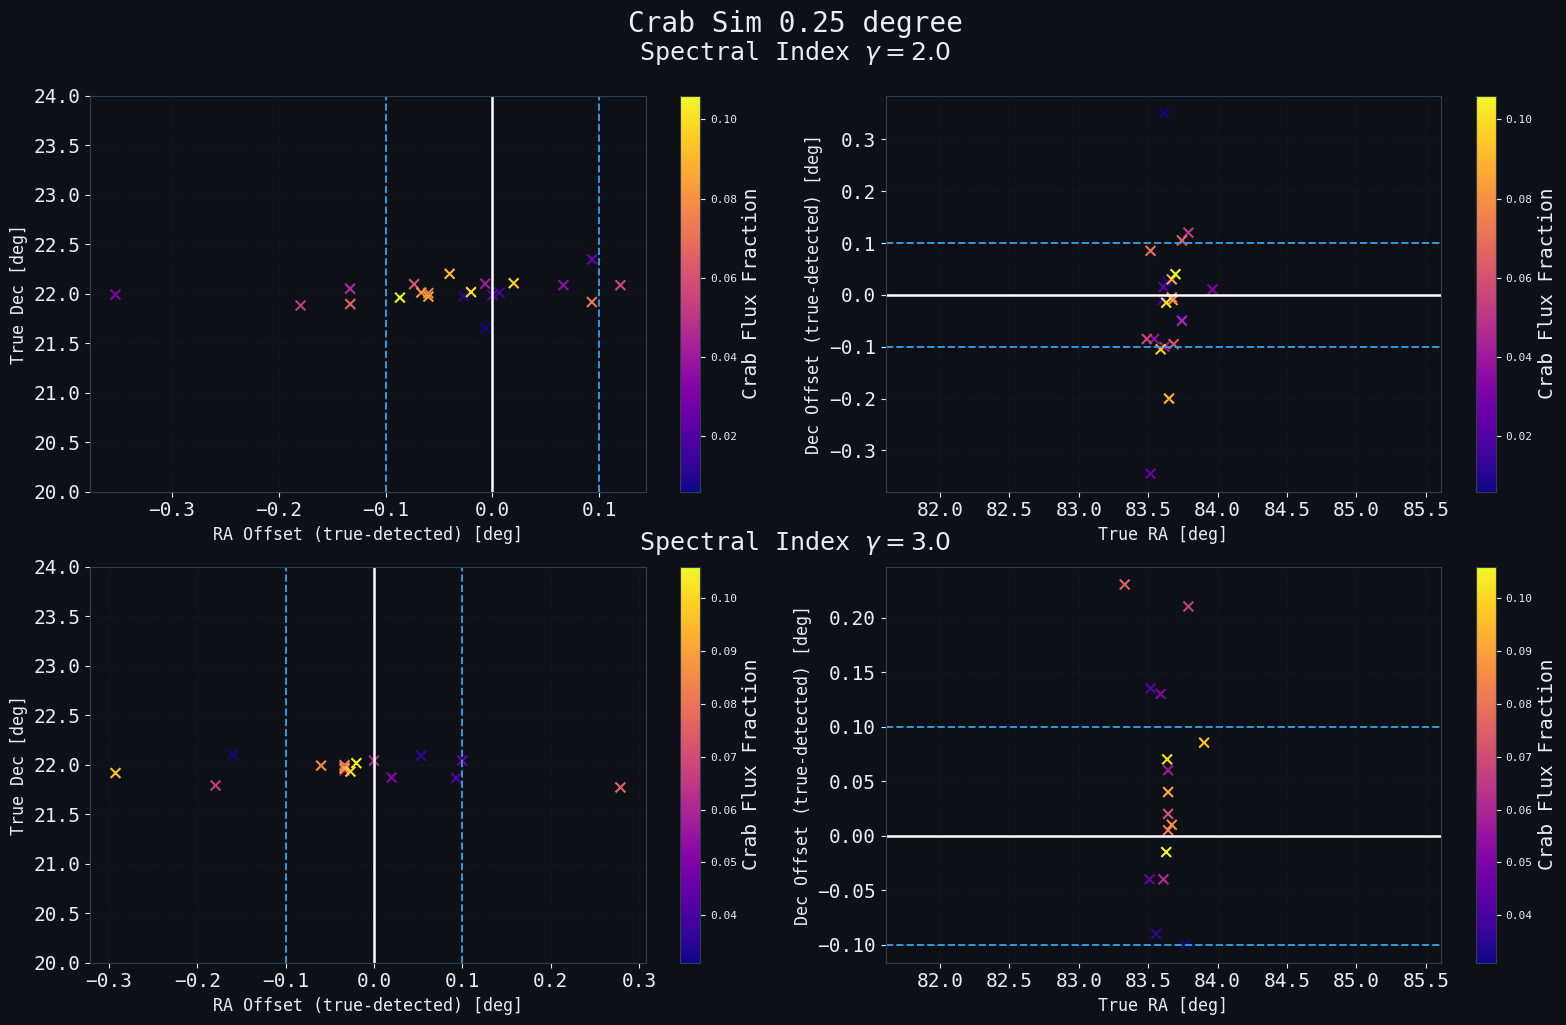

In [27]:
plot_blob_offsets(blobs0p25, true_ra, true_dec, extension=0.25)

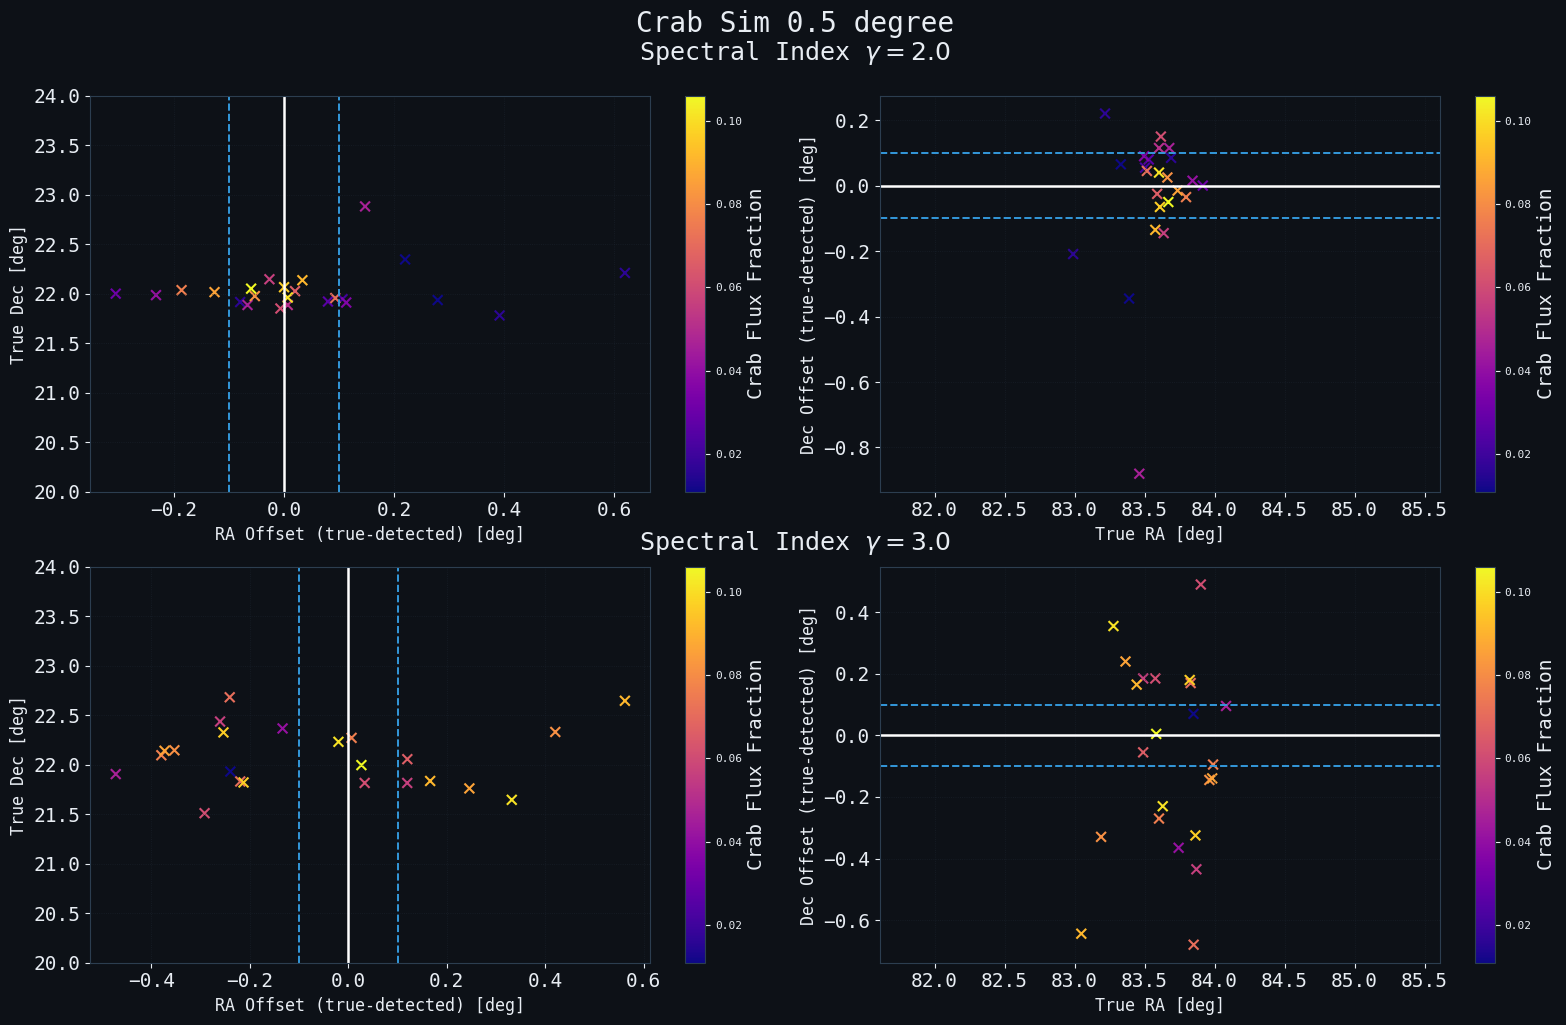

In [28]:
plot_blob_offsets(blobs0p5, true_ra, true_dec, extension=0.5)

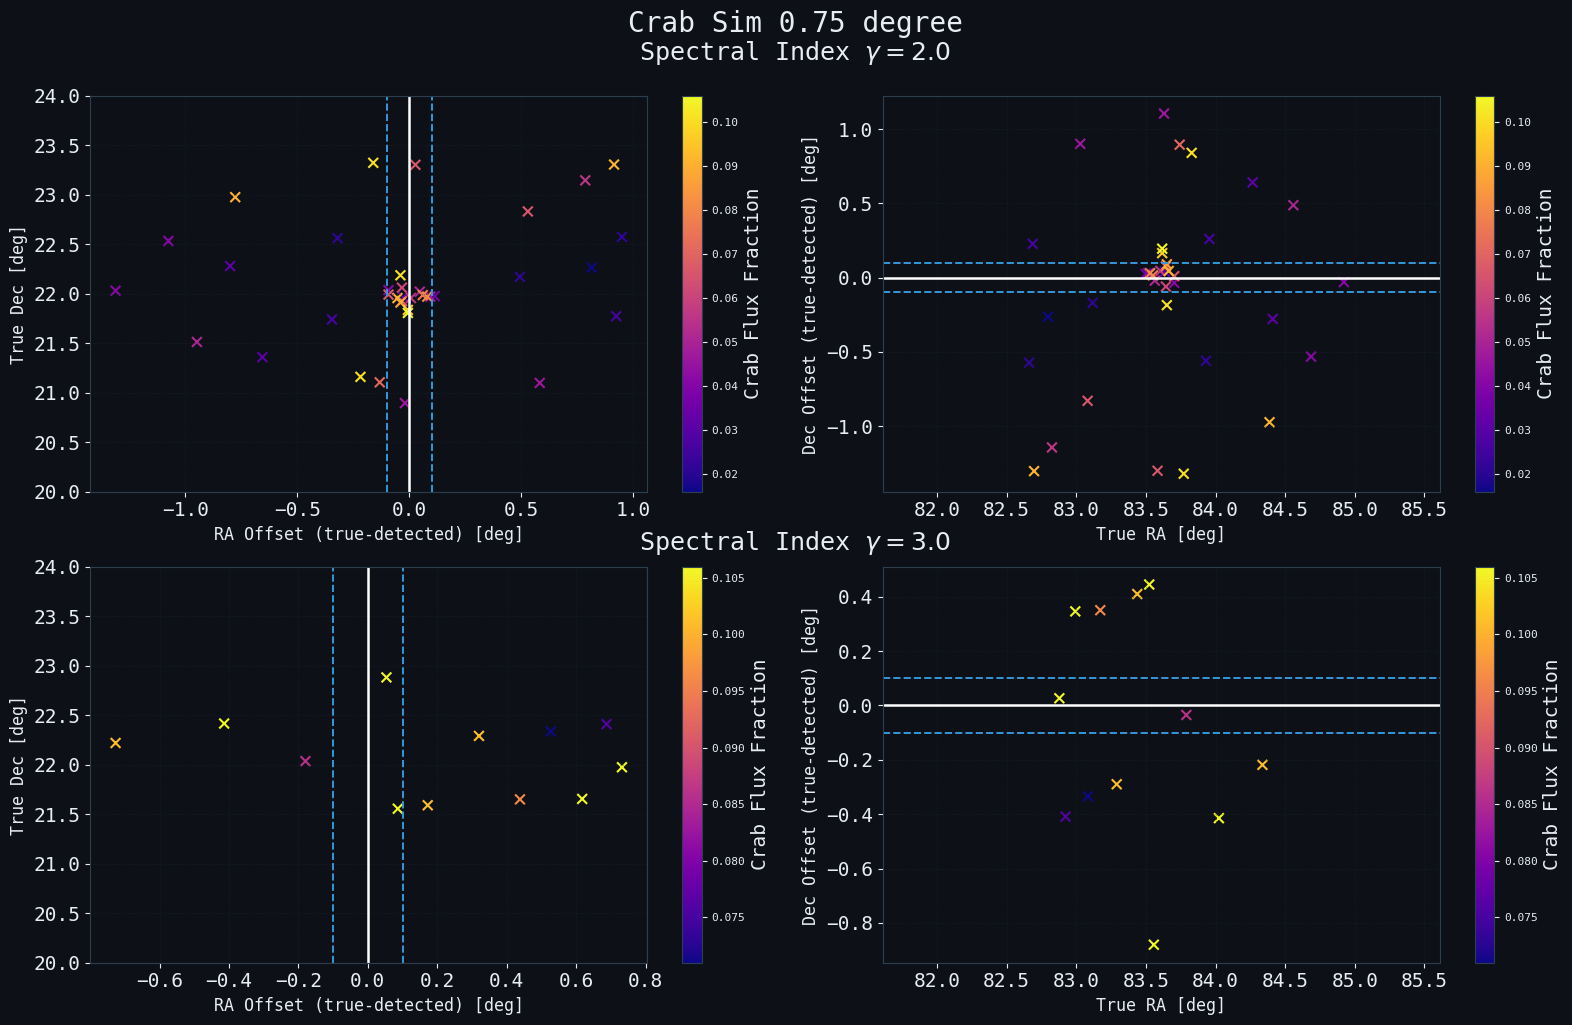

In [29]:
plot_blob_offsets(blobs0p75, true_ra, true_dec, extension=0.75)

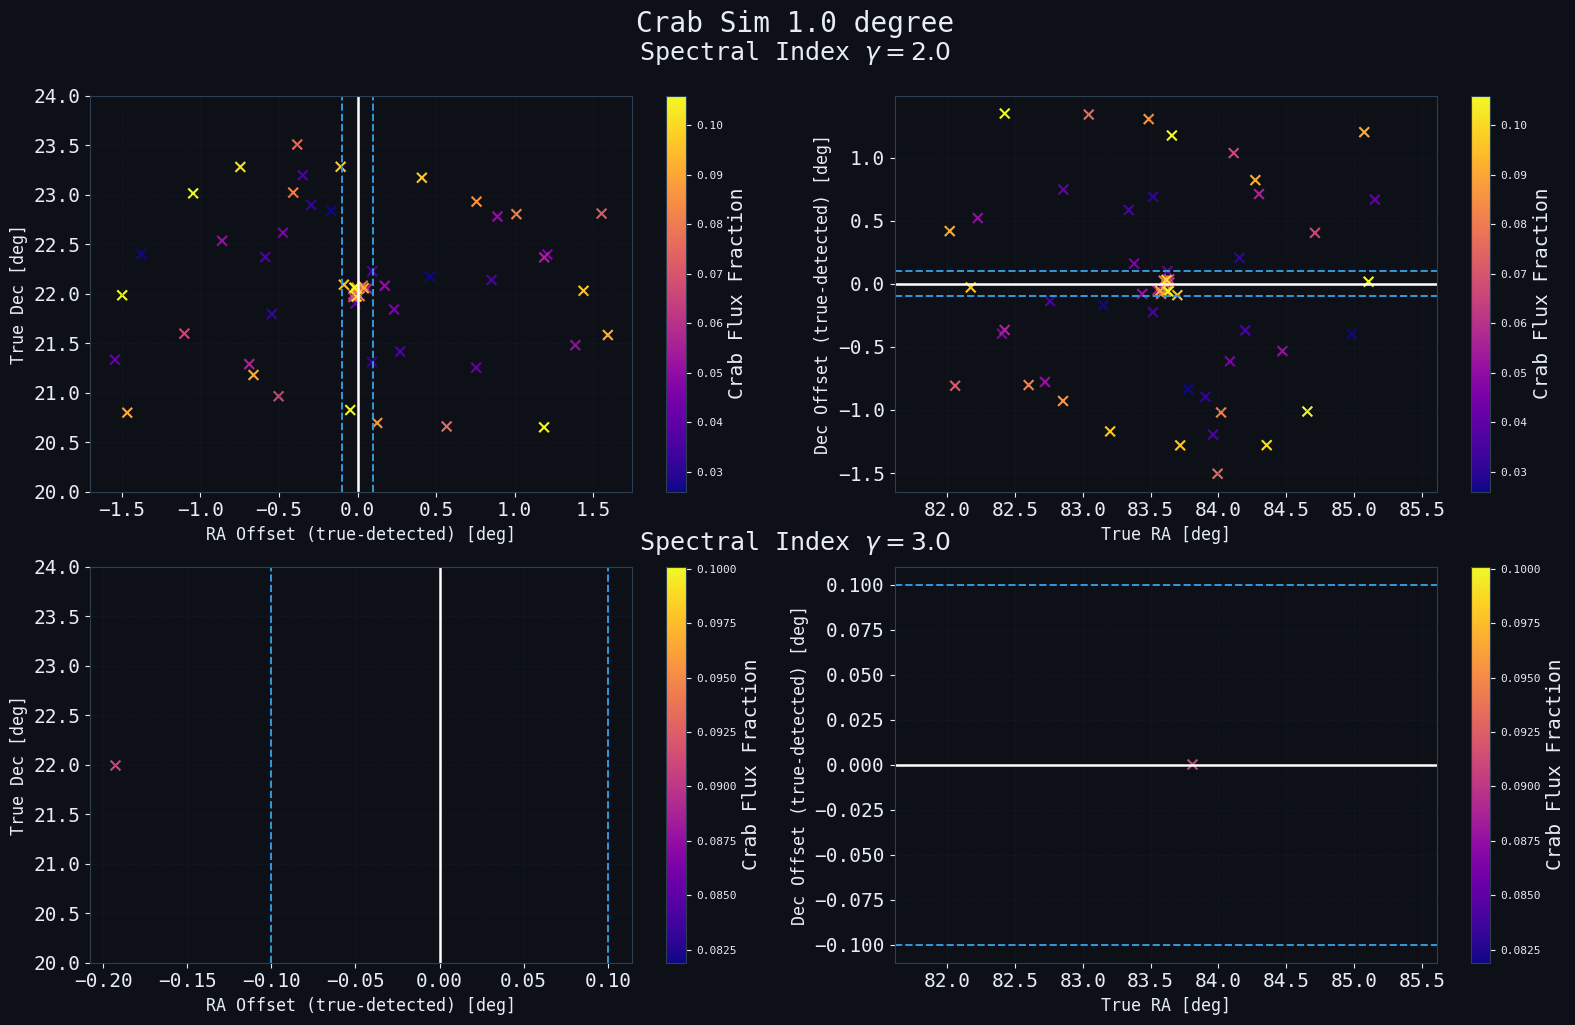

In [30]:
plot_blob_offsets(blobs1p0, true_ra, true_dec, extension=1.0)

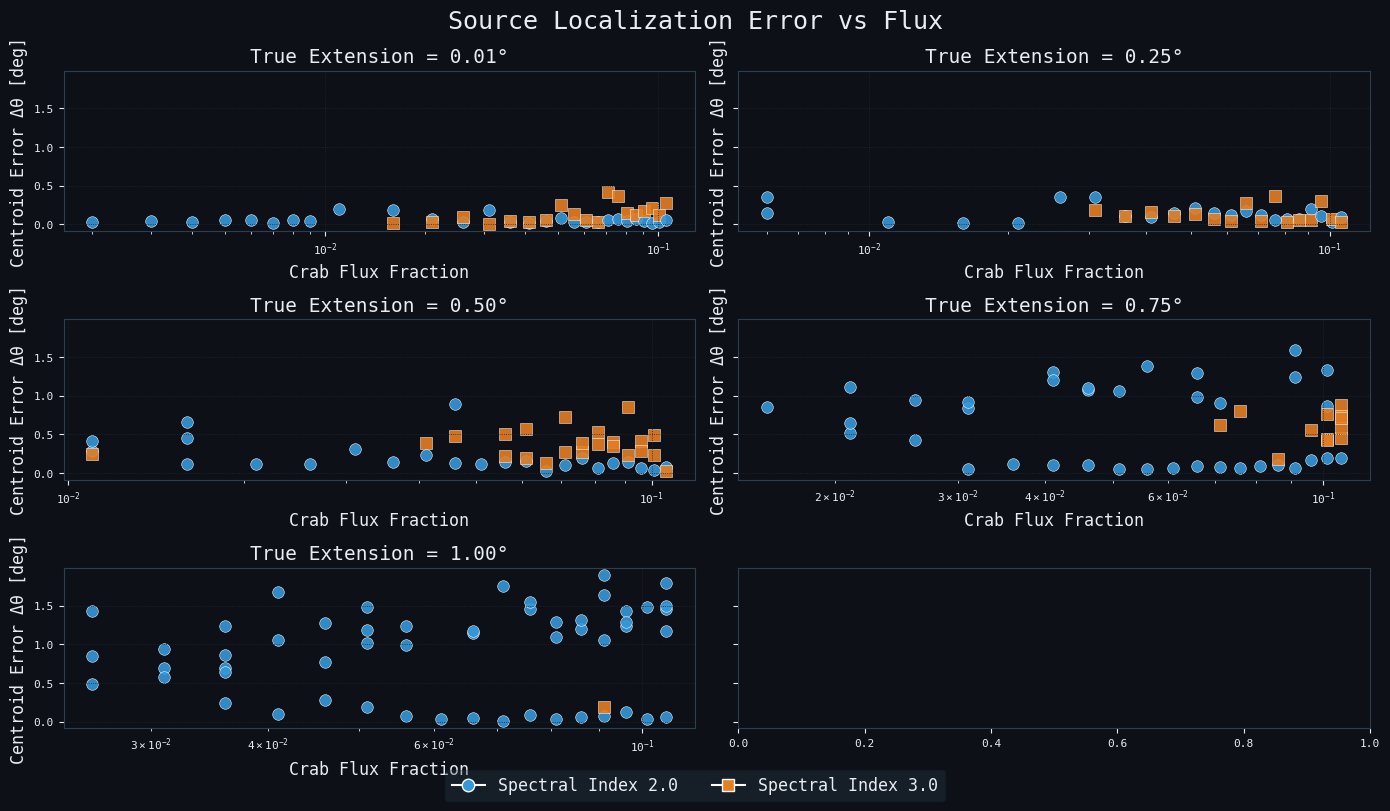

In [87]:
fig, axes = plt.subplots(3, 2, figsize=(14,8), sharey=True)#, sharex=True)
fig.patch.set_facecolor(BG)

axes = axes.flatten()

datasets = [
    (records0p01, "True Extension = 0.01°"),
    (records0p25, "True Extension = 0.25°"),
    (records0p5,  "True Extension = 0.50°"),
    (records0p75, "True Extension = 0.75°"),
    (records1p0,  "True Extension = 1.00°"),
]

for ax, (records, title) in zip(axes, datasets):

    for r in records:

        if r['status'] != 'detected':
            continue

        for b in (r['ps_kept'] + r['ext_kept']):

            ra  = b.get('ra',  b.get('l_deg'))
            dec = b.get('dec', b.get('b_deg'))

            if ra is None or dec is None:
                continue

            dra  = true_ra  - ra
            ddec = true_dec - dec

            ang_err = np.sqrt(dra**2 + ddec**2)

            col  = C_IDX2 if r['spectral_index'] == 2.0 else C_IDX3
            mark = 'o' if r['spectral_index'] == 2.0 else 's'

            ax.scatter(
                r['flux_fraction'],
                ang_err,
                color=col,
                marker=mark,
                s=70,
                edgecolors='white',
                linewidths=0.4,
                alpha=0.9
            )

    ax.set_title(title, fontsize=14)
    ax.set_xscale("log")
    ax.grid(True, ls=':')

    ax.set_xlabel("Crab Flux Fraction", fontsize=12)
    ax.set_ylabel("Centroid Error Δθ [deg]", fontsize=12)

fig.suptitle("Source Localization Error vs Flux", fontsize=18)
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_IDX2,
           markersize=9, markeredgecolor='white', label='Spectral Index 2.0'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_IDX3,
           markersize=9, markeredgecolor='white', label='Spectral Index 3.0'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=12, framealpha=0.3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

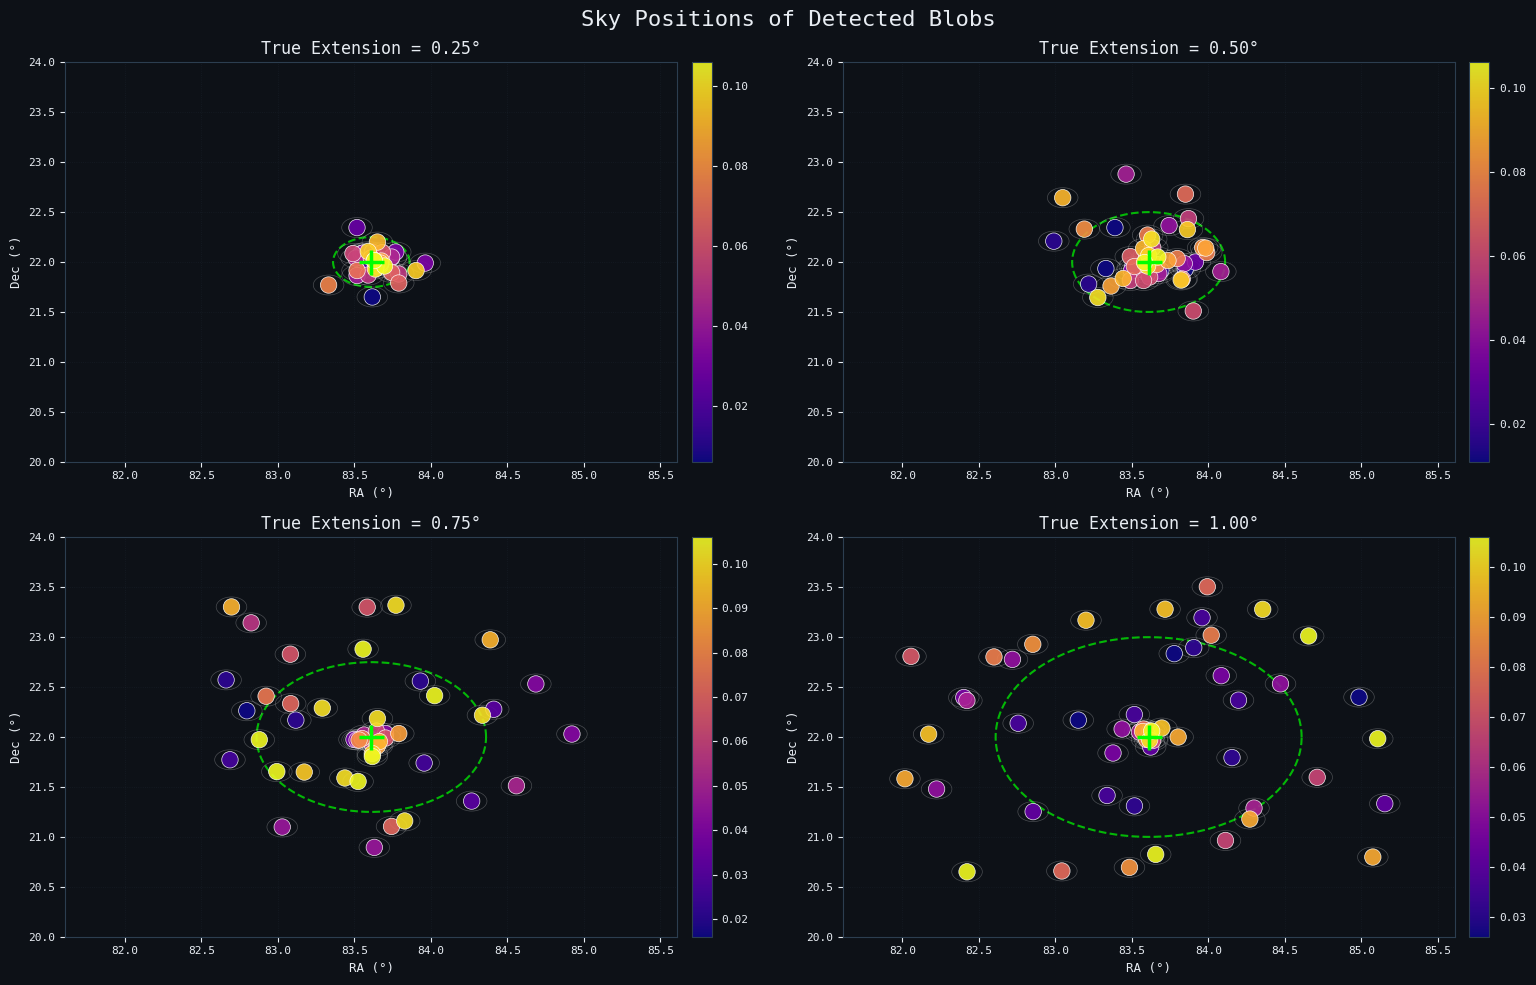

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.patch.set_facecolor(BG)

datasets = [
    (records0p25, 0.25, "True Extension = 0.25°"),
    (records0p5,  0.50, "True Extension = 0.50°"),
    (records0p75, 0.75, "True Extension = 0.75°"),
    (records1p0,  1.00, "True Extension = 1.00°"),
]
axes = axes.flatten()

for ax, (records, ext, title) in zip(axes, datasets):

    ax.set_facecolor(BG)

    ras, decs, fluxes, radii = [], [], [], []

    for r in records:
        if r['status'] != 'detected':
            continue
        for b in (r['ps_kept'] + r['ext_kept']):
            ra  = b.get('ra',  b.get('l_deg'))
            dec = b.get('dec', b.get('b_deg'))

            if ra is None or dec is None:continue
            ras.append(ra)
            decs.append(dec)
            fluxes.append(r['flux_fraction'])
            radii.append(b.get('circle_radius', 0.1))

    if ras:
        sc = ax.scatter(ras, decs,c=fluxes,cmap='plasma',s=140,edgecolors='white',linewidths=0.5,alpha=0.9,zorder=4)
        cb = fig.colorbar(sc, ax=ax, pad=0.02)
        for ra, dec, rad in zip(ras, decs, radii):
            ax.add_patch(plt.Circle((ra, dec),rad,fill=False,edgecolor='white',lw=0.5,alpha=0.25,zorder=3))

    theta = np.linspace(0, 2*np.pi, 300)

    ax.plot(true_ra, true_dec,marker='+',color='lime',ms=18,mew=2.5,zorder=6,label='True position')
    ax.plot(true_ra + ext*np.cos(theta),true_dec + ext*np.sin(theta),color='lime',lw=1.5,ls='--',alpha=0.7,label=f'True extension {ext:.2f}°')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('RA (°)')
    ax.set_ylabel('Dec (°)')
    ax.invert_xaxis()
    ax.grid(True, ls=':', alpha=0.5)
    ax.set_xlim(true_ra-2, true_ra+2)
    ax.set_ylim(true_dec-2, true_dec+2)


fig.suptitle("Sky Positions of Detected Blobs ", fontsize=16)

fig.tight_layout()
plt.show()
plt.close(fig)


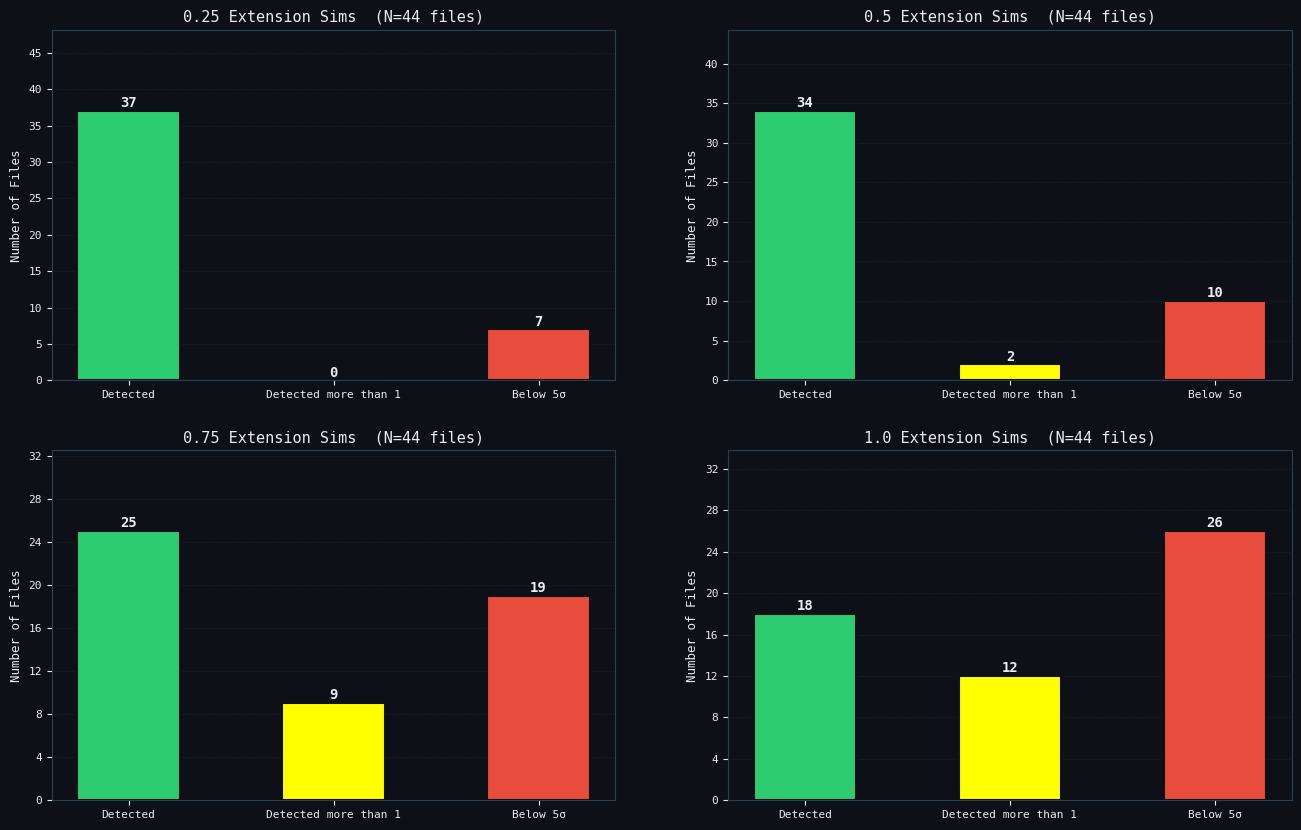

In [ ]:

det=0
below=0
nob=0
morethantwo=0
fig = plt.figure(figsize=(16, 10))
for r in records0p25:
    if r['status'] == 'detected':
        det+=1
        if r['ps_kept'] and r['ext_kept']:
            morethantwo+=1
    elif r['status'] == 'below_threshold':
        below+=1

C_MORETHANTWO='yellow'
ax = fig.add_subplot(221)
labels = ['Detected', 'Detected more than 1', 'Below 5σ']
counts = [det, morethantwo, below]
bars   = ax.bar(labels, counts, color=[C_DET, C_MORETHANTWO,  C_BEL, C_NOB],
                width=0.5, edgecolor=BG, linewidth=1.5, zorder=3)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(cnt), ha='center', va='bottom', color=FG, fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Files')
ax.set_title(f'0.25 Extension Sims  (N={len(records)} files)')
ax.set_ylim(0, max(counts) * 1.3 if counts else 1)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')

det=0
below=0
nob=0
morethantwo=0
for r in records0p5:
    if r['status'] == 'detected':
        det+=1
        if r['ps_kept'] and r['ext_kept']:
            morethantwo+=1
    elif r['status'] == 'below_threshold':
        below+=1

ax = fig.add_subplot(222)
labels = ['Detected', 'Detected more than 1', 'Below 5σ']
counts = [det, morethantwo, below]
bars   = ax.bar(labels, counts, color=[C_DET, C_MORETHANTWO,  C_BEL, C_NOB],
                width=0.5, edgecolor=BG, linewidth=1.5, zorder=3)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(cnt), ha='center', va='bottom', color=FG, fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Files')
ax.set_title(f'0.5 Extension Sims  (N={len(records)} files)')
ax.set_ylim(0, max(counts) * 1.3 if counts else 1)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')

det=0
below=0
nob=0
morethantwo=0
for r in records0p75:
    if r['status'] == 'detected':
        det+=1
        if r['ps_kept'] and r['ext_kept']:
            morethantwo+=1
    elif r['status'] == 'below_threshold':
        below+=1

ax = fig.add_subplot(223)
labels = ['Detected', 'Detected more than 1', 'Below 5σ']
counts = [det, morethantwo, below]
bars   = ax.bar(labels, counts, color=[C_DET, C_MORETHANTWO,  C_BEL, C_NOB],
                width=0.5, edgecolor=BG, linewidth=1.5, zorder=3)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(cnt), ha='center', va='bottom', color=FG, fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Files')
ax.set_title(f'0.75 Extension Sims  (N={len(records)} files)')
ax.set_ylim(0, max(counts) * 1.3 if counts else 1)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')

det=0
below=0
nob=0
morethantwo=0
for r in records1p0:
    if r['status'] == 'detected':
        det+=1
        if r['ps_kept'] and r['ext_kept']:
            morethantwo+=1
    elif r['status'] == 'below_threshold':
        below+=1

ax = fig.add_subplot(224)
labels = ['Detected', 'Detected more than 1', 'Below 5σ']
counts = [det, morethantwo, below]
bars   = ax.bar(labels, counts, color=[C_DET, C_MORETHANTWO,  C_BEL, C_NOB],
                width=0.5, edgecolor=BG, linewidth=1.5, zorder=3)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(cnt), ha='center', va='bottom', color=FG, fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Files')
ax.set_title(f'1.0 Extension Sims  (N={len(records)} files)')
ax.set_ylim(0, max(counts) * 1.3 if counts else 1)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')


In [82]:
def calculate_tpn(records, allff, match_radius, ext=None):
    (tp_files, fp_multi_files, fp_wrong_files, fn_files,
     tn_clean_files, tn_ghost_files,
     tp_blobs, fp_blobs) = classify_detections(
        records, true_ra, true_dec, match_radius=match_radius
    )

    n_tp       = len(tp_files)
    n_fp_multi = len(fp_multi_files)
    n_fp_wrong = len(fp_wrong_files)
    n_fp       = n_fp_multi + n_fp_wrong
    n_fn       = len(fn_files)
    n_tn_clean = len(tn_clean_files)
    n_tn_ghost = len(tn_ghost_files)
    n_tn       = n_tn_clean + n_tn_ghost

    precision = n_tp / (n_tp + n_fp) if (n_tp + n_fp) > 0 else float('nan')
    recall    = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else float('nan')
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else float('nan'))

    # ── 6-cell confusion matrix ───────────────────────────────────────────
    #                  ≥5σ             <5σ
    #  1 blob matched   TP             TN_ghost  ← sub-threshold but detected
    #  1 blob wrong     FP_wrong       TN_ghost  (collapsed into ghost row)
    #  >1 blob          FP_multi       TN_ghost  (collapsed into ghost row)
    #  0 blobs          FN             TN_clean

    # Layout as 3-row × 2-col matrix for heatmap:
    #            ≥5σ          <5σ
    #  TP / --   n_tp         0            (only meaningful for ≥5σ)
    #  FP        n_fp         n_tn_ghost
    #  FN / TN   n_fn         n_tn_clean
    data = [
        [n_tp,       0          ],   # row: single correct detection
        [n_fp_wrong, n_tn_ghost ],   # row: 1 wrong blob
        [n_fp_multi, 0          ],   # row: >1 blobs
        [n_fn,       n_tn_clean ],   # row: nothing detected
    ]
    row_labels = [
        '1 blob · matched  (TP)',
        '1 blob · wrong pos (FP)',
        '>1 blobs  (FP)',
        '0 blobs  (FN / TN)',
    ]
    col_labels = [r'≥5$\sigma$', r'<5$\sigma$']

    print(f"\n{'='*55}")
    print(f"  Match radius : {match_radius}°")
    print(f"  True source  : RA={true_ra}°  Dec={true_dec}°")
    print(f"{'='*55}")
    print(f"  TP              : {n_tp:>4}   (≥5σ · 1 blob · matched)")
    print(f"  FP wrong pos    : {n_fp_wrong:>4}   (≥5σ · 1 blob · unmatched)")
    print(f"  FP multi-blob   : {n_fp_multi:>4}   (≥5σ · >1 blob)")
    print(f"  FN              : {n_fn:>4}   (≥5σ · 0 blobs)")
    print(f"  TN clean        : {n_tn_clean:>4}   (<5σ · 0 blobs)")
    print(f"  TN ghost        : {n_tn_ghost:>4}   (<5σ · ≥1 spurious blob)")
    print(f"{'─'*55}")
    print(f"  TP blobs        : {len(tp_blobs):>4}")
    print(f"  FP blobs        : {len(fp_blobs):>4}")
    print(f"{'─'*55}")
    print(f"  Precision       : {precision:.3f}")
    print(f"  Recall          : {recall:.3f}")
    print(f"  F1 score        : {f1:.3f}")
    print(f"{'='*55}\n")

    # ── figure ────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6))
    fig.suptitle(
    f'Crab Sim  Extension={ext}  ·  match radius = {match_radius}°',
    fontsize=13, fontweight='bold', color=FG, y=-0.02,
    )
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    fig.patch.set_facecolor(BG)

    # 4×2 confusion matrix
    ax1 = fig.add_subplot(121)
    seaborn.heatmap(
        data,
        ax=ax1,
        xticklabels=col_labels,
        yticklabels=row_labels,
        annot=True, fmt='d', square=True, cmap='Blues',
        linewidths=0.5, linecolor='gray',
    )
    ax1.set_xlabel('Simulation')
    ax1.set_ylabel('Detection')
    ax1.xaxis.tick_top()
    ax1.xaxis.set_label_position('top')
    ax1.set_title(
        f'N={len(records)}\n'
        f'Precision={precision:.2f}  Recall={recall:.2f}  F1={f1:.2f}'
    )

    # TPR vs flux fraction
    ax2 = fig.add_subplot(122)
    for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'), (3.0, C_IDX3, 'Index 3.0')]:
        ffs, tprs = [], []
        for ff in allff:
            tp_sub = [r for r in tp_files      if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
            fn_sub = [r for r in fn_files      if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
            fp_sub = [r for r in fp_multi_files + fp_wrong_files
                                               if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
            denom  = len(tp_sub) + len(fn_sub) + len(fp_sub)
            if denom == 0:
                continue
            ffs.append(ff)
            tprs.append(len(tp_sub) / denom)
        if ffs:
            ax2.plot(ffs, tprs, color=col, marker='o', lw=2, ms=7, label=lbl, zorder=3)
            ax2.fill_between(ffs, tprs, alpha=0.12, color=col)

    ax2.axhline(1.0, color=FG, lw=0.7, ls=':', alpha=0.4)
    ax2.axhline(0.5, color=FG, lw=0.7, ls=':', alpha=0.4)
    ax2.set_xlabel('Flux Fraction')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('TPR vs Flux Fraction\n(TP / TP+FN+FP)')



  Match radius : 0.3°
  True source  : RA=83.61°  Dec=22.0°
  TP              :   45   (≥5σ · 1 blob · matched)
  FP wrong pos    :    2   (≥5σ · 1 blob · unmatched)
  FP multi-blob   :    0   (≥5σ · >1 blob)
  FN              :    0   (≥5σ · 0 blobs)
  TN clean        :   11   (<5σ · 0 blobs)
  TN ghost        :    0   (<5σ · ≥1 spurious blob)
───────────────────────────────────────────────────────
  TP blobs        :   45
  FP blobs        :    2
───────────────────────────────────────────────────────
  Precision       : 0.957
  Recall          : 1.000
  F1 score        : 0.978



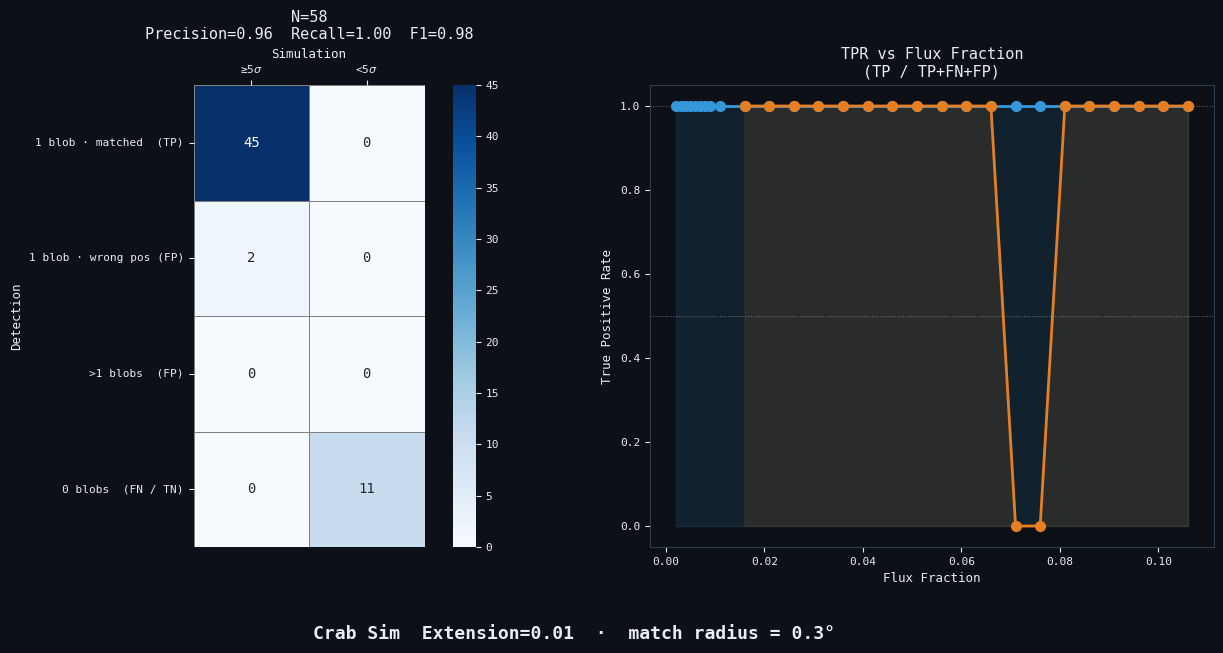

In [86]:
calculate_tpn(records0p01, allff0p01, match_radius=0.3, ext=0.01)



  Match radius : 0.3°
  True source  : RA=83.61°  Dec=22.0°
  TP              :   33   (≥5σ · 1 blob · matched)
  FP wrong pos    :    3   (≥5σ · 1 blob · unmatched)
  FP multi-blob   :    1   (≥5σ · >1 blob)
  FN              :    0   (≥5σ · 0 blobs)
  TN clean        :    7   (<5σ · 0 blobs)
  TN ghost        :    0   (<5σ · ≥1 spurious blob)
───────────────────────────────────────────────────────
  TP blobs        :   34
  FP blobs        :    4
───────────────────────────────────────────────────────
  Precision       : 0.892
  Recall          : 1.000
  F1 score        : 0.943



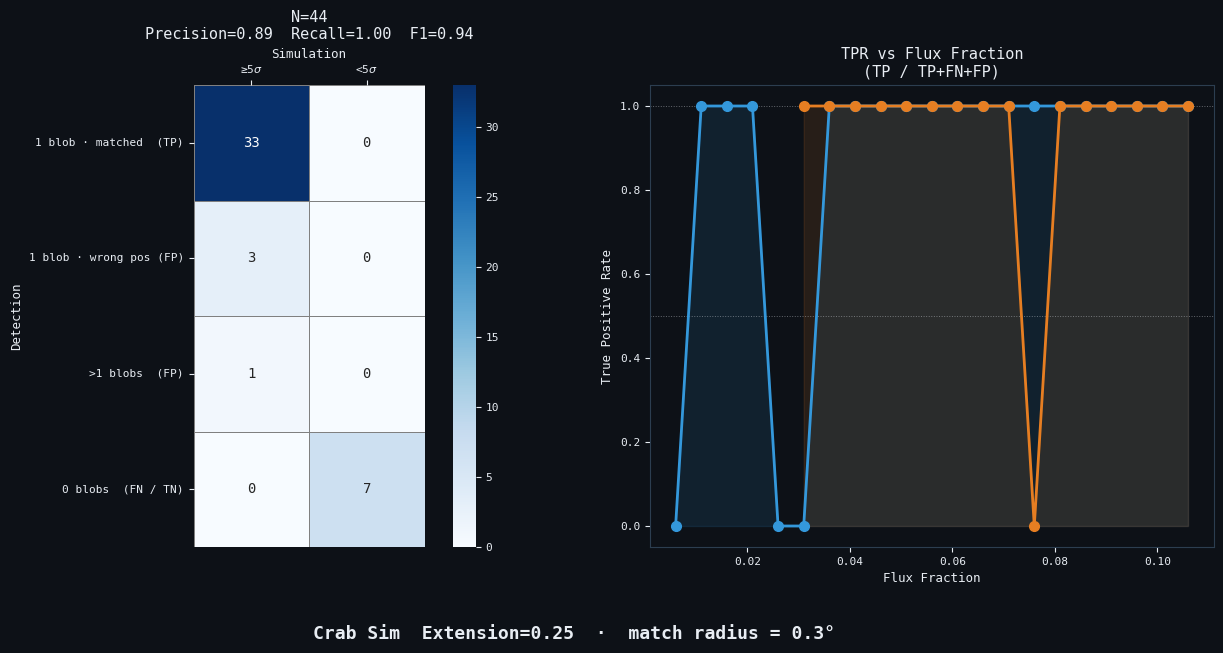

In [64]:
calculate_tpn(records0p25, allff0p25, match_radius=0.3, ext=0.25)



  Match radius : 0.3°
  True source  : RA=83.61°  Dec=22.0°
  TP              :   20   (≥5σ · 1 blob · matched)
  FP wrong pos    :    2   (≥5σ · 1 blob · unmatched)
  FP multi-blob   :   12   (≥5σ · >1 blob)
  FN              :    0   (≥5σ · 0 blobs)
  TN clean        :   10   (<5σ · 0 blobs)
  TN ghost        :    0   (<5σ · ≥1 spurious blob)
───────────────────────────────────────────────────────
  TP blobs        :   30
  FP blobs        :   17
───────────────────────────────────────────────────────
  Precision       : 0.588
  Recall          : 1.000
  F1 score        : 0.741



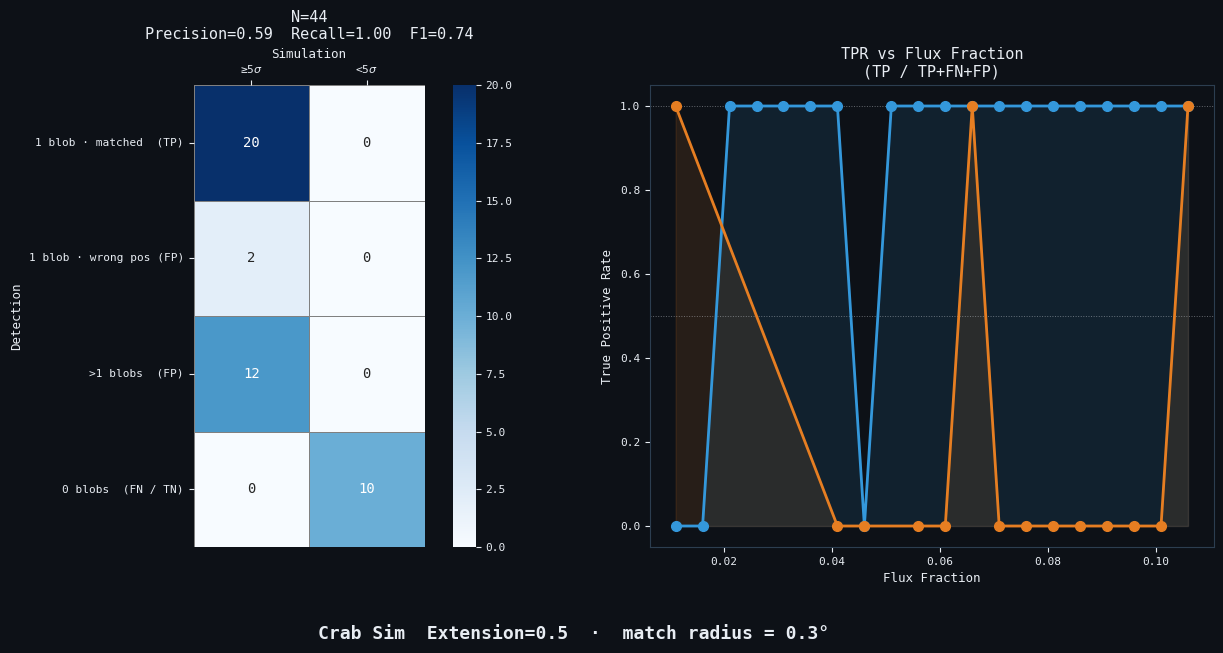

In [65]:
calculate_tpn(records0p5, allff0p5, match_radius=0.3, ext=0.5)


  Match radius : 0.3°
  True source  : RA=83.61°  Dec=22.0°
  TP              :    8   (≥5σ · 1 blob · matched)
  FP wrong pos    :    4   (≥5σ · 1 blob · unmatched)
  FP multi-blob   :   13   (≥5σ · >1 blob)
  FN              :    0   (≥5σ · 0 blobs)
  TN clean        :   19   (<5σ · 0 blobs)
  TN ghost        :    0   (<5σ · ≥1 spurious blob)
───────────────────────────────────────────────────────
  TP blobs        :   17
  FP blobs        :   32
───────────────────────────────────────────────────────
  Precision       : 0.320
  Recall          : 1.000
  F1 score        : 0.485



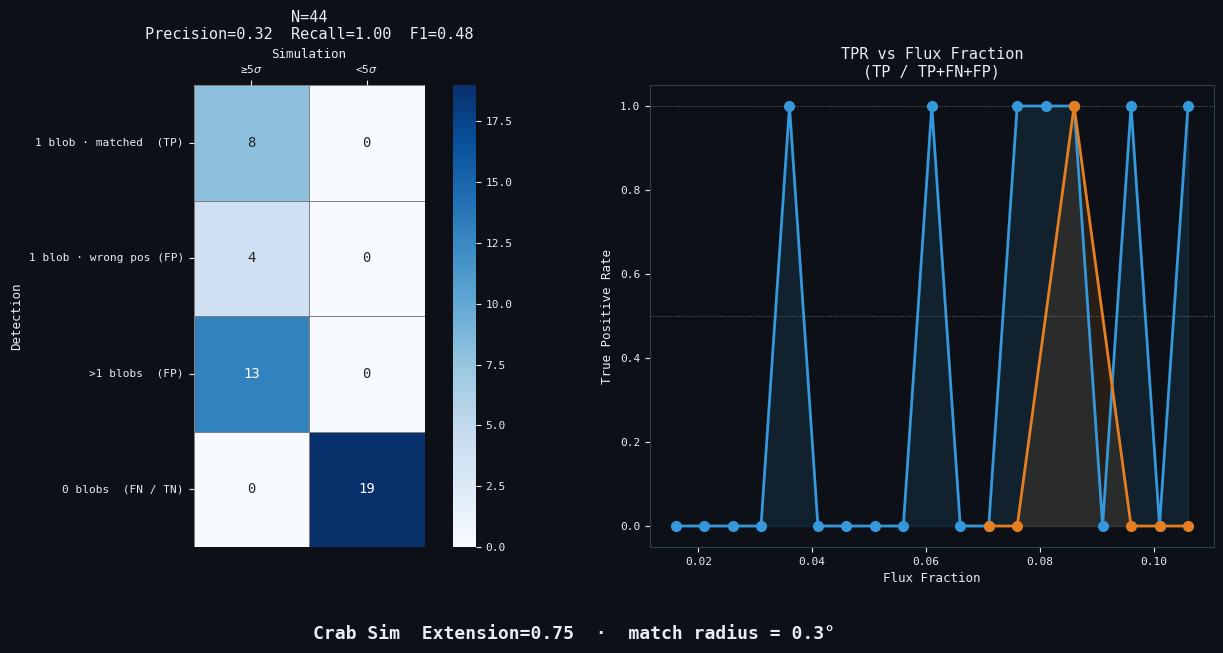

In [66]:
calculate_tpn(records0p75, allff0p75, match_radius=0.3, ext=0.75)


  Match radius : 0.3°
  True source  : RA=83.61°  Dec=22.0°
  TP              :    2   (≥5σ · 1 blob · matched)
  FP wrong pos    :    0   (≥5σ · 1 blob · unmatched)
  FP multi-blob   :   16   (≥5σ · >1 blob)
  FN              :    0   (≥5σ · 0 blobs)
  TN clean        :   26   (<5σ · 0 blobs)
  TN ghost        :    0   (<5σ · ≥1 spurious blob)
───────────────────────────────────────────────────────
  TP blobs        :   16
  FP blobs        :   39
───────────────────────────────────────────────────────
  Precision       : 0.111
  Recall          : 1.000
  F1 score        : 0.200



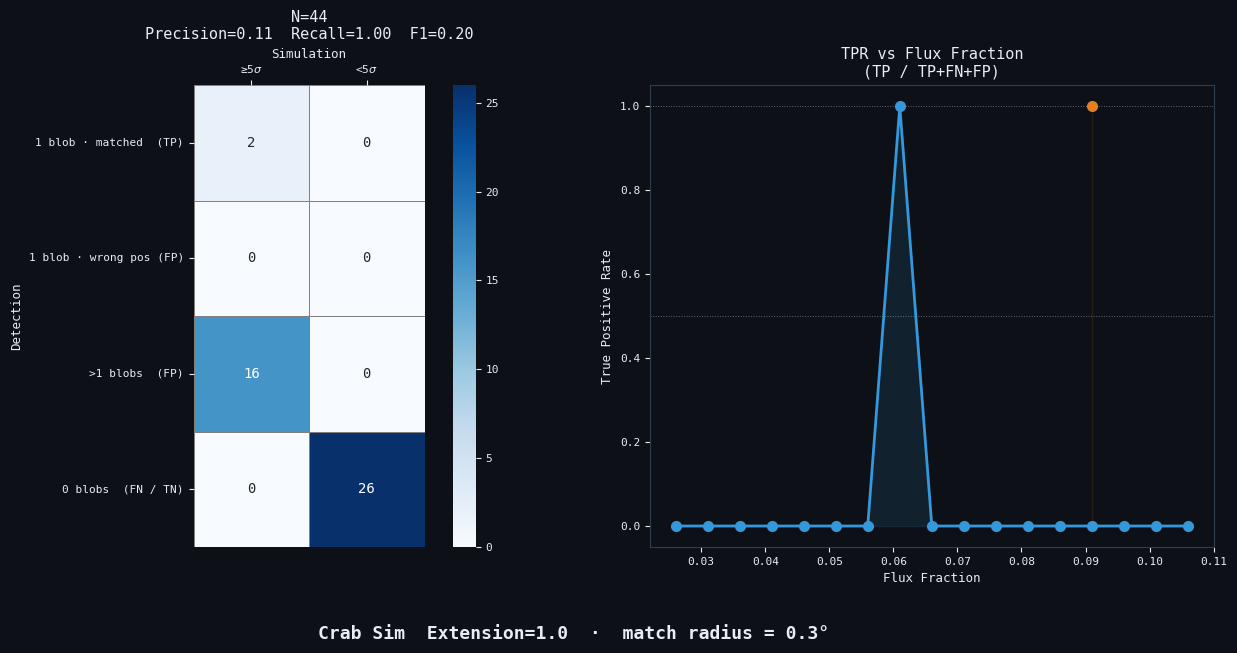

In [67]:
calculate_tpn(records1p0, allff1p0, match_radius=0.3, ext=1.0)

In [ ]:

# fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
# fig1.suptitle('Blob Detection Diagnostics  ·  All Extensions  ·  All Indices',
#               fontsize=13, fontweight='bold', color=FG, y=0.98)
# fig1.patch.set_facecolor(BG)

# ax = axes1[0, 0]
# for r in records:
#     if r['flux_fraction'] is None or r['max_significance'] is None:
#         continue
#     col  = C_DET if r['status'] == 'detected' else C_BEL
#     mark = 'o' if r['spectral_index'] == 2.0 else 's'
#     ax.scatter(r['flux_fraction'], r['max_significance'],
#                color=col, marker=mark, s=90, zorder=3,
#                edgecolors='white', linewidths=0.4, alpha=0.9)

# ax.axhline(5.0, color='white', lw=1.2, ls='--', alpha=0.6, label='5σ threshold')
# ax.set_xlabel('Flux Fraction')
# ax.set_ylabel('Max Significance (σ)')
# ax.set_title('Max Significance vs Flux Fraction')
# ax.set_xscale('log')
# ax.grid(True, ls=':')
# ax.legend(handles=[
#     mpatches.Patch(color=C_DET, label='Detected'),
#     mpatches.Patch(color=C_BEL, label='Below threshold / no blobs'),
#     Line2D([0],[0], marker='o', color='none', markerfacecolor=FG, markersize=7, label='Index 2.0'),
#     Line2D([0],[0], marker='s', color='none', markerfacecolor=FG, markersize=7, label='Index 3.0'),
#     Line2D([0],[0], color='white', ls='--', lw=1.2, label='5σ threshold'),
# ], loc='upper left')

# # ── 1b: Detection fraction vs flux fraction per spectral index ────────────────
# ax = axes1[0, 1]
# for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'), (3.0, C_IDX3, 'Index 3.0')]:
#     ffs   = sorted(set(r['flux_fraction'] for r in records
#                        if r['spectral_index'] == idx_val and r['flux_fraction'] is not None))
#     fracs = []
#     for ff in ffs:
#         subset = [r for r in records if r['spectral_index'] == idx_val and r['flux_fraction'] == ff]
#         fracs.append(sum(1 for r in subset if r['status'] == 'detected') / len(subset) if subset else 0)
#     ax.plot(ffs, fracs, color=col, marker='o', lw=2, ms=7, label=lbl, zorder=3)
#     ax.fill_between(ffs, fracs, alpha=0.12, color=col)

# ax.axhline(1.0, color=FG, lw=0.7, ls=':', alpha=0.4)
# ax.axhline(0.5, color=FG, lw=0.7, ls=':', alpha=0.4)
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Detection Fraction')
# ax.set_title('Detection Rate vs Flux Fraction')
# ax.set_ylim(-0.05, 1.15);  ax.set_xscale('log')
# ax.grid(True, ls=':');  ax.legend()

# # ── 1c: Status breakdown bar chart ────────────────────────────────────────────
# ax = axes1[1, 0]
# labels = ['Detected', 'Below 5σ', 'No Blobs']
# counts = [len(det), len(below), len(nob)]
# bars   = ax.bar(labels, counts, color=[C_DET, C_BEL, C_NOB],
#                 width=0.5, edgecolor=BG, linewidth=1.5, zorder=3)
# for bar, cnt in zip(bars, counts):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
#             str(cnt), ha='center', va='bottom', color=FG, fontsize=10, fontweight='bold')
# ax.set_ylabel('Number of Files')
# ax.set_title(f'Status Breakdown  (N={len(records)} files)')
# ax.set_ylim(0, max(counts) * 1.3 if counts else 1)
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.grid(True, axis='y', ls=':')

# # ── 1d: Max significance distribution by status ───────────────────────────────
# ax = axes1[1, 1]
# bins = np.linspace(2.5, 25, 18)
# if below:
#     ax.hist([r['max_significance'] for r in below if r['max_significance']],
#             bins=bins, color=C_BEL, alpha=0.75, label='Below threshold', edgecolor=BG, lw=0.8)
# if det:
#     ax.hist([r['max_significance'] for r in det if r['max_significance']],
#             bins=bins, color=C_DET, alpha=0.75, label='Detected', edgecolor=BG, lw=0.8)
# ax.axvline(5.0, color='white', lw=1.4, ls='--', label='5σ', zorder=5)
# ax.set_xlabel('Max Significance (σ)');  ax.set_ylabel('Count')
# ax.set_title('Significance Distribution by Status')
# ax.legend();  ax.grid(True, ls=':')

# fig1.tight_layout(rect=[0, 0, 1, 0.97])
# plt.show();  plt.close(fig1)
# print("Fig 1 done")


# # ══════════════════════════════════════════════════════════════════════════════
# # Figure 2 — Detected blob properties
# # ══════════════════════════════════════════════════════════════════════════════
# fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
# fig2.suptitle('Detected Blob Properties  ·  PS + EXT Kept',
#               fontsize=13, fontweight='bold', color=FG, y=0.98)
# fig2.patch.set_facecolor(BG)

# # ── 2a: Centroid offset from true position ────────────────────────────────────
# ax = axes2[0, 0]
# if blobs:
#     ra_off  = [(b['ra']  - true_ra)  * np.cos(np.radians(true_dec)) * 60 for b in blobs]
#     dec_off = [(b['dec'] - true_dec) * 60 for b in blobs]
#     sc = ax.scatter(ra_off, dec_off,
#                     c=[b['flux_fraction'] for b in blobs], cmap='plasma',
#                     s=100, edgecolors='white', linewidths=0.4, zorder=3, alpha=0.9)
#     cb = fig2.colorbar(sc, ax=ax, pad=0.02)
#     cb.set_label('Flux Fraction', color=FG)
#     cb.ax.yaxis.set_tick_params(color=FG)
#     plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

# ax.axhline(0, color='white', lw=0.8, ls=':')
# ax.axvline(0, color='white', lw=0.8, ls=':')
# ax.plot(0, 0, marker='+', color='white', ms=14, mew=2, zorder=5, label='True position')
# theta = np.linspace(0, 2*np.pi, 200)
# ax.plot(0.25*60*np.cos(theta), 0.25*60*np.sin(theta),
#         color=C_DET, lw=1.2, ls='--', alpha=0.5, label='0.25° reference ring')
# ax.set_xlabel('ΔRA cos(dec) [arcmin]');  ax.set_ylabel('ΔDec [arcmin]')
# ax.set_title('Centroid Offset from True Position')
# ax.set_aspect('equal');  ax.legend(loc='upper right');  ax.grid(True, ls=':')

# # ── 2b: Detected radius vs flux fraction, split by blob type ─────────────────
# ax = axes2[0, 1]
# if blobs:
#     for blob_label, col, lbl in [('PS', C_IDX2, 'Point Source'), ('EXT', C_IDX3, 'Extended')]:
#         sub = [b for b in blobs if b.get('label') == blob_label]
#         if sub:
#             ax.scatter([b['flux_fraction'] for b in sub],
#                        [b['circle_radius']  for b in sub],
#                        color=col, s=80, edgecolors='white', linewidths=0.4,
#                        label=lbl, zorder=3, alpha=0.9)

# ax.axhline(0.25, color=FG, lw=1.2, ls='--', alpha=0.6, label='0.25° reference')
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Detected Circle Radius (°)')
# ax.set_title('Detected Radius vs Flux Fraction\n(PS vs EXT blobs)')
# ax.set_xscale('log');  ax.legend();  ax.grid(True, ls=':')

# # ── 2c: Mean blobs per file vs flux fraction ──────────────────────────────────
# ax = axes2[1, 0]
# ff_ndets = defaultdict(list)
# for r in records:
#     if r['flux_fraction'] is not None:
#         ff_ndets[r['flux_fraction']].append(r['n_detected'])

# ffs_sorted = sorted(ff_ndets)
# means = [np.mean(ff_ndets[ff]) for ff in ffs_sorted]
# stds  = [np.std(ff_ndets[ff])  for ff in ffs_sorted]
# xpos  = np.arange(len(ffs_sorted))

# ax.bar(xpos, means, color=C_DET, alpha=0.75, edgecolor=BG, linewidth=1.2, zorder=3)
# ax.errorbar(xpos, means, yerr=stds, fmt='none', color='white', capsize=4, lw=1.5, zorder=4)
# ax.set_xticks(xpos)
# ax.set_xticklabels([f'{ff:.3f}' for ff in ffs_sorted], rotation=45, ha='right')
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Mean # Blobs Detected')
# ax.set_title('Mean Blobs per File vs Flux Fraction\n(error = 1σ across files)')
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.grid(True, axis='y', ls=':')

# # ── 2d: PS vs EXT blob count per file ────────────────────────────────────────
# ax = axes2[1, 1]
# ps_counts  = [len(r['ps_kept'])  for r in det]
# ext_counts = [len(r['ext_kept']) for r in det]
# ax.scatter(ps_counts, ext_counts,
#            c=[r['flux_fraction'] for r in det], cmap='plasma',
#            s=90, edgecolors='white', linewidths=0.4, zorder=3, alpha=0.9)
# ax.set_xlabel('# PS Blobs Kept');  ax.set_ylabel('# EXT Blobs Kept')
# ax.set_title('PS vs EXT Blob Count per Detected File')
# ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.grid(True, ls=':')

# fig2.tight_layout(rect=[0, 0, 1, 0.97])
# plt.show();  plt.close(fig2)
# print("Fig 2 done")


# # ══════════════════════════════════════════════════════════════════════════════
# # Figure 3 — Per spectral index deep-dive
# # ══════════════════════════════════════════════════════════════════════════════
# fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
# fig3.suptitle('Max Significance vs Flux Fraction — Split by Spectral Index',
#               fontsize=12, fontweight='bold', color=FG, y=1.01)
# fig3.patch.set_facecolor(BG)

# for ax, idx_val, col, lbl in [
#         (axes3[0], 2.0, C_IDX2, 'Spectral Index = 2.0'),
#         (axes3[1], 3.0, C_IDX3, 'Spectral Index = 3.0')]:
#     sub = [r for r in records if r['spectral_index'] == idx_val
#            and r['flux_fraction'] is not None and r['max_significance'] is not None]
#     for r in sub:
#         mk   = 'D' if r['status'] == 'detected' else 'X'
#         ecol = 'white' if r['status'] == 'detected' else C_BEL
#         ax.scatter(r['flux_fraction'], r['max_significance'],
#                    color=col, marker=mk, s=100, zorder=3,
#                    edgecolors=ecol, linewidths=0.8, alpha=0.9)
#         ax.annotate(f"{r['n_detected']}",
#                     (r['flux_fraction'], r['max_significance']),
#                     textcoords='offset points', xytext=(5, 4),
#                     fontsize=7, color=FG, alpha=0.75)

#     sub_s = sorted(sub, key=lambda x: x['flux_fraction'])
#     ax.plot([r['flux_fraction'] for r in sub_s],
#             [r['max_significance'] for r in sub_s],
#             color=col, lw=1.0, ls='--', alpha=0.4, zorder=2)

#     ax.axhline(5.0, color='white', lw=1.2, ls='--', alpha=0.5, label='5σ')
#     ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Max Significance (σ)')
#     ax.set_title(lbl);  ax.set_xscale('log');  ax.grid(True, ls=':')
#     ax.legend(handles=[
#         Line2D([0],[0], marker='D', color='none', markerfacecolor=col,
#                markeredgecolor='white', markersize=8, label='Detected'),
#         Line2D([0],[0], marker='X', color='none', markerfacecolor=col,
#                markeredgecolor=C_BEL,   markersize=8, label='Below threshold'),
#         Line2D([0],[0], color='white', ls='--', lw=1.2, label='5σ'),
#     ])

# fig3.tight_layout()
# plt.show();  plt.close(fig3)
# print("Fig 3 done")


# # ══════════════════════════════════════════════════════════════════════════════
# # Figure 4 — Sky positions of all detected blobs
# # ══════════════════════════════════════════════════════════════════════════════
# fig4, ax4 = plt.subplots(figsize=(8, 7))
# fig4.patch.set_facecolor(BG);  ax4.set_facecolor(BG)

# if blobs:
#     sc = ax4.scatter([b['ra']  for b in blobs],
#                      [b['dec'] for b in blobs],
#                      c=[b['flux_fraction'] for b in blobs], cmap='plasma',
#                      s=140, edgecolors='white', linewidths=0.5, zorder=4, alpha=0.9)
#     for b in blobs:
#         ax4.add_patch(plt.Circle((b['ra'], b['dec']), b['circle_radius'],
#                                  fill=False, edgecolor='white', lw=0.5, alpha=0.25, zorder=3))
#     cb = fig4.colorbar(sc, ax=ax4, pad=0.02)
#     cb.set_label('Flux Fraction', color=FG)
#     cb.ax.yaxis.set_tick_params(color=FG)
#     plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

# theta = np.linspace(0, 2*np.pi, 300)
# ax4.plot(true_ra, true_dec, marker='+', color='lime', ms=18, mew=2.5, zorder=6, label='True position')
# ax4.plot(true_ra + 0.25*np.cos(theta), true_dec + 0.25*np.sin(theta),
#          color='lime', lw=1.5, ls='--', alpha=0.7, label='True extension 0.25°')

# ax4.set_xlabel('RA (°)', labelpad=6);  ax4.set_ylabel('Dec (°)', labelpad=6)
# ax4.set_title('Sky Positions of All Detected Blobs\n'
#               'Circles = detected radius  ·  colour = flux fraction', fontsize=10)
# ax4.invert_xaxis();  ax4.legend(loc='upper right');  ax4.grid(True, ls=':', alpha=0.5)

# fig4.tight_layout()
# plt.show();  plt.close(fig4)
# print("Fig 4 done")

# # ══════════════════════════════════════════════════════════════════════════════
# # True-positive / false-positive / false-negative classification
# # ══════════════════════════════════════════════════════════════════════════════


# tp_files, fp_files, fn_files, tn_files, tp_blobs, fp_blobs = classify_detections(
#     records, true_ra, true_dec
# )

# # ── Summary stats ─────────────────────────────────────────────────────────────
# n_tp = len(tp_files)
# n_fp = len(fp_files)
# n_fn = len(fn_files)
# n_tn = len(tn_files)

# precision = n_tp / (n_tp + n_fp) if (n_tp + n_fp) > 0 else float('nan')
# recall    = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else float('nan')
# f1        = (2 * precision * recall / (precision + recall)
#              if (precision + recall) > 0 else float('nan'))

# print(f"\n{'='*50}")
# print(f"  Match radius : {MATCH_RADIUS_DEG}°")
# print(f"  True source  : RA={true_ra}°  Dec={true_dec}°")
# print(f"{'='*50}")
# print(f"  TP files     : {n_tp:>4}   (detected + matched)")
# print(f"  FP files     : {n_fp:>4}   (detected + not matched)")
# print(f"  FN files     : {n_fn:>4}   (≥5σ map  + no detection)")
# print(f"  TN files     : {n_tn:>4}   (below threshold)")
# print(f"{'─'*50}")
# print(f"  TP blobs     : {len(tp_blobs):>4}")
# print(f"  FP blobs     : {len(fp_blobs):>4}")
# print(f"{'─'*50}")
# print(f"  Precision    : {precision:.3f}")
# print(f"  Recall       : {recall:.3f}")
# print(f"  F1 score     : {f1:.3f}")
# print(f"{'='*50}\n")


# # ══════════════════════════════════════════════════════════════════════════════
# # Figure 5 — TP / FP / FN breakdown
# # ══════════════════════════════════════════════════════════════════════════════
# C_TP = '#2ECC71'
# C_FP = '#E74C3C'
# C_FN = '#F39C12'
# C_TN = '#95A5A6'

# fig5, axes5 = plt.subplots(2, 2, figsize=(14, 10))
# fig5.suptitle(f'TP / FP / FN Analysis  ·  match radius = {MATCH_RADIUS_DEG}°',
#               fontsize=13, fontweight='bold', color=FG, y=0.98)
# fig5.patch.set_facecolor(BG)

# # ── 5a: Confusion bar chart ───────────────────────────────────────────────────
# ax = axes5[0, 0]
# labels  = ['TP', 'FP', 'FN', 'TN']
# counts  = [n_tp, n_fp, n_fn, n_tn]
# colors  = [C_TP, C_FP, C_FN, C_TN]
# bars    = ax.bar(labels, counts, color=colors, width=0.5,
#                  edgecolor=BG, linewidth=1.5, zorder=3)
# for bar, cnt in zip(bars, counts):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
#             str(cnt), ha='center', va='bottom',
#             color=FG, fontsize=11, fontweight='bold')
# ax.set_ylabel('Number of Files')
# ax.set_title(f'File-level Confusion  (N={len(records)})\n'
#              f'Precision={precision:.2f}  Recall={recall:.2f}  F1={f1:.2f}')
# ax.set_ylim(0, max(counts) * 1.35 if counts else 1)
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.grid(True, axis='y', ls=':')

# # ── 5b: Detection rate (TP / TP+FN) vs flux fraction ─────────────────────────
# ax = axes5[0, 1]
# for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'), (3.0, C_IDX3, 'Index 3.0')]:
#     ffs, tprs = [], []
#     for ff in all_ff:
#         tp_sub = [r for r in tp_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
#         fn_sub = [r for r in fn_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
#         fp_sub = [r for r in fp_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
#         denom  = len(tp_sub) + len(fn_sub) + len(fp_sub)
#         if denom == 0:
#             continue
#         ffs.append(ff)
#         tprs.append(len(tp_sub) / denom)
#     if ffs:
#         ax.plot(ffs, tprs, color=col, marker='o', lw=2, ms=7, label=lbl, zorder=3)
#         ax.fill_between(ffs, tprs, alpha=0.12, color=col)

# ax.axhline(1.0, color=FG, lw=0.7, ls=':', alpha=0.4)
# ax.axhline(0.5, color=FG, lw=0.7, ls=':', alpha=0.4)
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('True Positive Rate')
# ax.set_title('TPR vs Flux Fraction\n(TP / TP+FN+FP per flux bin)')
# ax.set_ylim(-0.05, 1.15);  ax.set_xscale('log')
# ax.grid(True, ls=':');  ax.legend()

# # ── 5c: Angular separation of all detected blobs from true position ───────────
# ax = axes5[1, 0]
# all_detected_blobs = tp_blobs + fp_blobs
# if all_detected_blobs:
#     seps  = [b['sep_deg'] for b in all_detected_blobs]
#     colors_sep = [C_TP if b['match'] else C_FP for b in all_detected_blobs]
#     ax.hist([b['sep_deg'] for b in tp_blobs],
#             bins=30, color=C_TP, alpha=0.75, label=f'TP blobs ({len(tp_blobs)})',
#             edgecolor=BG, lw=0.8)
#     ax.hist([b['sep_deg'] for b in fp_blobs],
#             bins=30, color=C_FP, alpha=0.75, label=f'FP blobs ({len(fp_blobs)})',
#             edgecolor=BG, lw=0.8)
# ax.axvline(MATCH_RADIUS_DEG, color='white', lw=1.4, ls='--',
#            label=f'Match radius ({MATCH_RADIUS_DEG}°)', zorder=5)
# ax.set_xlabel('Angular Separation from True Position (°)')
# ax.set_ylabel('Count')
# ax.set_title('Blob Separation from True Source')
# ax.legend();  ax.grid(True, ls=':')

# # ── 5d: TP / FP / FN counts vs flux fraction (stacked) ───────────────────────
# ax = axes5[1, 1]
# tp_per_ff = [sum(1 for r in tp_files if r['flux_fraction'] == ff) for ff in all_ff]
# fp_per_ff = [sum(1 for r in fp_files if r['flux_fraction'] == ff) for ff in all_ff]
# fn_per_ff = [sum(1 for r in fn_files if r['flux_fraction'] == ff) for ff in all_ff]
# xpos      = np.arange(len(all_ff))

# ax.bar(xpos, tp_per_ff, color=C_TP, alpha=0.85, label='TP', edgecolor=BG, lw=1)
# ax.bar(xpos, fp_per_ff, bottom=tp_per_ff, color=C_FP, alpha=0.85, label='FP', edgecolor=BG, lw=1)
# ax.bar(xpos, fn_per_ff,
#        bottom=[t+f for t,f in zip(tp_per_ff, fp_per_ff)],
#        color=C_FN, alpha=0.85, label='FN', edgecolor=BG, lw=1)
# ax.set_xticks(xpos)
# ax.set_xticklabels([f'{ff:.3f}' for ff in all_ff], rotation=45, ha='right')
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('File Count')
# ax.set_title('TP / FP / FN per Flux Fraction')
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.legend();  ax.grid(True, axis='y', ls=':')

# fig5.tight_layout(rect=[0, 0, 1, 0.97])
# plt.show();  plt.close(fig5)
# print("Fig 5 done")

In [ ]:
# []
# fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
# fig1.suptitle('Blob Detection Diagnostics  ·  All Extensions  ·  All Indices',
#               fontsize=13, fontweight='bold', color=FG, y=0.98)
# fig1.patch.set_facecolor(BG)

# ax = axes1[0, 0]
# for r in records:
#     if r['flux_fraction'] is None or r['max_significance'] is None:
#         continue
#     col  = C_DET if r['status'] == 'detected' else C_BEL
#     mark = 'o' if r['spectral_index'] == 2.0 else 's'
#     ax.scatter(r['flux_fraction'], r['max_significance'],
#                color=col, marker=mark, s=90, zorder=3,
#                edgecolors='white', linewidths=0.4, alpha=0.9)

# ax.axhline(5.0, color='white', lw=1.2, ls='--', alpha=0.6, label='5σ threshold')
# ax.set_xlabel('Flux Fraction')
# ax.set_ylabel('Max Significance (σ)')
# ax.set_title('Max Significance vs Flux Fraction')
# ax.set_xscale('log')
# ax.grid(True, ls=':')
# ax.legend(handles=[
#     mpatches.Patch(color=C_DET, label='Detected'),
#     mpatches.Patch(color=C_BEL, label='Below threshold / no blobs'),
#     Line2D([0],[0], marker='o', color='none', markerfacecolor=FG, markersize=7, label='Index 2.0'),
#     Line2D([0],[0], marker='s', color='none', markerfacecolor=FG, markersize=7, label='Index 3.0'),
#     Line2D([0],[0], color='white', ls='--', lw=1.2, label='5σ threshold'),
# ], loc='upper left')

# # ── 1b: Detection fraction vs flux fraction per spectral index ────────────────
# ax = axes1[0, 1]
# for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'), (3.0, C_IDX3, 'Index 3.0')]:
#     ffs   = sorted(set(r['flux_fraction'] for r in records
#                        if r['spectral_index'] == idx_val and r['flux_fraction'] is not None))
#     fracs = []
#     for ff in ffs:
#         subset = [r for r in records if r['spectral_index'] == idx_val and r['flux_fraction'] == ff]
#         fracs.append(sum(1 for r in subset if r['status'] == 'detected') / len(subset) if subset else 0)
#     ax.plot(ffs, fracs, color=col, marker='o', lw=2, ms=7, label=lbl, zorder=3)
#     ax.fill_between(ffs, fracs, alpha=0.12, color=col)

# ax.axhline(1.0, color=FG, lw=0.7, ls=':', alpha=0.4)
# ax.axhline(0.5, color=FG, lw=0.7, ls=':', alpha=0.4)
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Detection Fraction')
# ax.set_title('Detection Rate vs Flux Fraction')
# ax.set_ylim(-0.05, 1.15);  ax.set_xscale('log')
# ax.grid(True, ls=':');  ax.legend()

# # ── 1c: Status breakdown bar chart ────────────────────────────────────────────
# ax = axes1[1, 0]
# labels = ['Detected', 'Below 5σ', 'No Blobs']
# counts = [len(det), len(below), len(nob)]
# bars   = ax.bar(labels, counts, color=[C_DET, C_BEL, C_NOB],
#                 width=0.5, edgecolor=BG, linewidth=1.5, zorder=3)
# for bar, cnt in zip(bars, counts):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
#             str(cnt), ha='center', va='bottom', color=FG, fontsize=10, fontweight='bold')
# ax.set_ylabel('Number of Files')
# ax.set_title(f'Status Breakdown  (N={len(records)} files)')
# ax.set_ylim(0, max(counts) * 1.3 if counts else 1)
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.grid(True, axis='y', ls=':')

# # ── 1d: Max significance distribution by status ───────────────────────────────
# ax = axes1[1, 1]
# bins = np.linspace(2.5, 25, 18)
# if below:
#     ax.hist([r['max_significance'] for r in below if r['max_significance']],
#             bins=bins, color=C_BEL, alpha=0.75, label='Below threshold', edgecolor=BG, lw=0.8)
# if det:
#     ax.hist([r['max_significance'] for r in det if r['max_significance']],
#             bins=bins, color=C_DET, alpha=0.75, label='Detected', edgecolor=BG, lw=0.8)
# ax.axvline(5.0, color='white', lw=1.4, ls='--', label='5σ', zorder=5)
# ax.set_xlabel('Max Significance (σ)');  ax.set_ylabel('Count')
# ax.set_title('Significance Distribution by Status')
# ax.legend();  ax.grid(True, ls=':')

# fig1.tight_layout(rect=[0, 0, 1, 0.97])
# plt.show();  plt.close(fig1)
# print("Fig 1 done")


# # ══════════════════════════════════════════════════════════════════════════════
# # Figure 2 — Detected blob properties
# # ══════════════════════════════════════════════════════════════════════════════
# fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
# fig2.suptitle('Detected Blob Properties  ·  PS + EXT Kept',
#               fontsize=13, fontweight='bold', color=FG, y=0.98)
# fig2.patch.set_facecolor(BG)

# # ── 2a: Centroid offset from true position ────────────────────────────────────
# ax = axes2[0, 0]
# if blobs:
#     ra_off  = [(b['ra']  - true_ra)  * np.cos(np.radians(true_dec)) * 60 for b in blobs]
#     dec_off = [(b['dec'] - true_dec) * 60 for b in blobs]
#     sc = ax.scatter(ra_off, dec_off,
#                     c=[b['flux_fraction'] for b in blobs], cmap='plasma',
#                     s=100, edgecolors='white', linewidths=0.4, zorder=3, alpha=0.9)
#     cb = fig2.colorbar(sc, ax=ax, pad=0.02)
#     cb.set_label('Flux Fraction', color=FG)
#     cb.ax.yaxis.set_tick_params(color=FG)
#     plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

# ax.axhline(0, color='white', lw=0.8, ls=':')
# ax.axvline(0, color='white', lw=0.8, ls=':')
# ax.plot(0, 0, marker='+', color='white', ms=14, mew=2, zorder=5, label='True position')
# theta = np.linspace(0, 2*np.pi, 200)
# ax.plot(0.25*60*np.cos(theta), 0.25*60*np.sin(theta),
#         color=C_DET, lw=1.2, ls='--', alpha=0.5, label='0.25° reference ring')
# ax.set_xlabel('ΔRA cos(dec) [arcmin]');  ax.set_ylabel('ΔDec [arcmin]')
# ax.set_title('Centroid Offset from True Position')
# ax.set_aspect('equal');  ax.legend(loc='upper right');  ax.grid(True, ls=':')

# # ── 2b: Detected radius vs flux fraction, split by blob type ─────────────────
# ax = axes2[0, 1]
# if blobs:
#     for blob_label, col, lbl in [('PS', C_IDX2, 'Point Source'), ('EXT', C_IDX3, 'Extended')]:
#         sub = [b for b in blobs if b.get('label') == blob_label]
#         if sub:
#             ax.scatter([b['flux_fraction'] for b in sub],
#                        [b['circle_radius']  for b in sub],
#                        color=col, s=80, edgecolors='white', linewidths=0.4,
#                        label=lbl, zorder=3, alpha=0.9)

# ax.axhline(0.25, color=FG, lw=1.2, ls='--', alpha=0.6, label='0.25° reference')
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Detected Circle Radius (°)')
# ax.set_title('Detected Radius vs Flux Fraction\n(PS vs EXT blobs)')
# ax.set_xscale('log');  ax.legend();  ax.grid(True, ls=':')

# # ── 2c: Mean blobs per file vs flux fraction ──────────────────────────────────
# ax = axes2[1, 0]
# ff_ndets = defaultdict(list)
# for r in records:
#     if r['flux_fraction'] is not None:
#         ff_ndets[r['flux_fraction']].append(r['n_detected'])

# ffs_sorted = sorted(ff_ndets)
# means = [np.mean(ff_ndets[ff]) for ff in ffs_sorted]
# stds  = [np.std(ff_ndets[ff])  for ff in ffs_sorted]
# xpos  = np.arange(len(ffs_sorted))

# ax.bar(xpos, means, color=C_DET, alpha=0.75, edgecolor=BG, linewidth=1.2, zorder=3)
# ax.errorbar(xpos, means, yerr=stds, fmt='none', color='white', capsize=4, lw=1.5, zorder=4)
# ax.set_xticks(xpos)
# ax.set_xticklabels([f'{ff:.3f}' for ff in ffs_sorted], rotation=45, ha='right')
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Mean # Blobs Detected')
# ax.set_title('Mean Blobs per File vs Flux Fraction\n(error = 1σ across files)')
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.grid(True, axis='y', ls=':')

# # ── 2d: PS vs EXT blob count per file ────────────────────────────────────────
# ax = axes2[1, 1]
# ps_counts  = [len(r['ps_kept'])  for r in det]
# ext_counts = [len(r['ext_kept']) for r in det]
# ax.scatter(ps_counts, ext_counts,
#            c=[r['flux_fraction'] for r in det], cmap='plasma',
#            s=90, edgecolors='white', linewidths=0.4, zorder=3, alpha=0.9)
# ax.set_xlabel('# PS Blobs Kept');  ax.set_ylabel('# EXT Blobs Kept')
# ax.set_title('PS vs EXT Blob Count per Detected File')
# ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.grid(True, ls=':')

# fig2.tight_layout(rect=[0, 0, 1, 0.97])
# plt.show();  plt.close(fig2)
# print("Fig 2 done")


# # ══════════════════════════════════════════════════════════════════════════════
# # Figure 3 — Per spectral index deep-dive
# # ══════════════════════════════════════════════════════════════════════════════
# fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
# fig3.suptitle('Max Significance vs Flux Fraction — Split by Spectral Index',
#               fontsize=12, fontweight='bold', color=FG, y=1.01)
# fig3.patch.set_facecolor(BG)

# for ax, idx_val, col, lbl in [
#         (axes3[0], 2.0, C_IDX2, 'Spectral Index = 2.0'),
#         (axes3[1], 3.0, C_IDX3, 'Spectral Index = 3.0')]:
#     sub = [r for r in records if r['spectral_index'] == idx_val
#            and r['flux_fraction'] is not None and r['max_significance'] is not None]
#     for r in sub:
#         mk   = 'D' if r['status'] == 'detected' else 'X'
#         ecol = 'white' if r['status'] == 'detected' else C_BEL
#         ax.scatter(r['flux_fraction'], r['max_significance'],
#                    color=col, marker=mk, s=100, zorder=3,
#                    edgecolors=ecol, linewidths=0.8, alpha=0.9)
#         ax.annotate(f"{r['n_detected']}",
#                     (r['flux_fraction'], r['max_significance']),
#                     textcoords='offset points', xytext=(5, 4),
#                     fontsize=7, color=FG, alpha=0.75)

#     sub_s = sorted(sub, key=lambda x: x['flux_fraction'])
#     ax.plot([r['flux_fraction'] for r in sub_s],
#             [r['max_significance'] for r in sub_s],
#             color=col, lw=1.0, ls='--', alpha=0.4, zorder=2)

#     ax.axhline(5.0, color='white', lw=1.2, ls='--', alpha=0.5, label='5σ')
#     ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Max Significance (σ)')
#     ax.set_title(lbl);  ax.set_xscale('log');  ax.grid(True, ls=':')
#     ax.legend(handles=[
#         Line2D([0],[0], marker='D', color='none', markerfacecolor=col,
#                markeredgecolor='white', markersize=8, label='Detected'),
#         Line2D([0],[0], marker='X', color='none', markerfacecolor=col,
#                markeredgecolor=C_BEL,   markersize=8, label='Below threshold'),
#         Line2D([0],[0], color='white', ls='--', lw=1.2, label='5σ'),
#     ])

# fig3.tight_layout()
# plt.show();  plt.close(fig3)
# print("Fig 3 done")


# # ══════════════════════════════════════════════════════════════════════════════
# # Figure 4 — Sky positions of all detected blobs
# # ══════════════════════════════════════════════════════════════════════════════
# fig4, ax4 = plt.subplots(figsize=(8, 7))
# fig4.patch.set_facecolor(BG);  ax4.set_facecolor(BG)

# if blobs:
#     sc = ax4.scatter([b['ra']  for b in blobs],
#                      [b['dec'] for b in blobs],
#                      c=[b['flux_fraction'] for b in blobs], cmap='plasma',
#                      s=140, edgecolors='white', linewidths=0.5, zorder=4, alpha=0.9)
#     for b in blobs:
#         ax4.add_patch(plt.Circle((b['ra'], b['dec']), b['circle_radius'],
#                                  fill=False, edgecolor='white', lw=0.5, alpha=0.25, zorder=3))
#     cb = fig4.colorbar(sc, ax=ax4, pad=0.02)
#     cb.set_label('Flux Fraction', color=FG)
#     cb.ax.yaxis.set_tick_params(color=FG)
#     plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

# theta = np.linspace(0, 2*np.pi, 300)
# ax4.plot(true_ra, true_dec, marker='+', color='lime', ms=18, mew=2.5, zorder=6, label='True position')
# ax4.plot(true_ra + 0.25*np.cos(theta), true_dec + 0.25*np.sin(theta),
#          color='lime', lw=1.5, ls='--', alpha=0.7, label='True extension 0.25°')

# ax4.set_xlabel('RA (°)', labelpad=6);  ax4.set_ylabel('Dec (°)', labelpad=6)
# ax4.set_title('Sky Positions of All Detected Blobs\n'
#               'Circles = detected radius  ·  colour = flux fraction', fontsize=10)
# ax4.invert_xaxis();  ax4.legend(loc='upper right');  ax4.grid(True, ls=':', alpha=0.5)

# fig4.tight_layout()
# plt.show();  plt.close(fig4)
# print("Fig 4 done")

# # ══════════════════════════════════════════════════════════════════════════════
# # True-positive / false-positive / false-negative classification
# # ══════════════════════════════════════════════════════════════════════════════


# tp_files, fp_files, fn_files, tn_files, tp_blobs, fp_blobs = classify_detections(
#     records, true_ra, true_dec
# )

# # ── Summary stats ─────────────────────────────────────────────────────────────
# n_tp = len(tp_files)
# n_fp = len(fp_files)
# n_fn = len(fn_files)
# n_tn = len(tn_files)

# precision = n_tp / (n_tp + n_fp) if (n_tp + n_fp) > 0 else float('nan')
# recall    = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else float('nan')
# f1        = (2 * precision * recall / (precision + recall)
#              if (precision + recall) > 0 else float('nan'))

# print(f"\n{'='*50}")
# print(f"  Match radius : {MATCH_RADIUS_DEG}°")
# print(f"  True source  : RA={true_ra}°  Dec={true_dec}°")
# print(f"{'='*50}")
# print(f"  TP files     : {n_tp:>4}   (detected + matched)")
# print(f"  FP files     : {n_fp:>4}   (detected + not matched)")
# print(f"  FN files     : {n_fn:>4}   (≥5σ map  + no detection)")
# print(f"  TN files     : {n_tn:>4}   (below threshold)")
# print(f"{'─'*50}")
# print(f"  TP blobs     : {len(tp_blobs):>4}")
# print(f"  FP blobs     : {len(fp_blobs):>4}")
# print(f"{'─'*50}")
# print(f"  Precision    : {precision:.3f}")
# print(f"  Recall       : {recall:.3f}")
# print(f"  F1 score     : {f1:.3f}")
# print(f"{'='*50}\n")


# # ══════════════════════════════════════════════════════════════════════════════
# # Figure 5 — TP / FP / FN breakdown
# # ══════════════════════════════════════════════════════════════════════════════
# C_TP = '#2ECC71'
# C_FP = '#E74C3C'
# C_FN = '#F39C12'
# C_TN = '#95A5A6'

# fig5, axes5 = plt.subplots(2, 2, figsize=(14, 10))
# fig5.suptitle(f'TP / FP / FN Analysis  ·  match radius = {MATCH_RADIUS_DEG}°',
#               fontsize=13, fontweight='bold', color=FG, y=0.98)
# fig5.patch.set_facecolor(BG)

# # ── 5a: Confusion bar chart ───────────────────────────────────────────────────
# ax = axes5[0, 0]
# labels  = ['TP', 'FP', 'FN', 'TN']
# counts  = [n_tp, n_fp, n_fn, n_tn]
# colors  = [C_TP, C_FP, C_FN, C_TN]
# bars    = ax.bar(labels, counts, color=colors, width=0.5,
#                  edgecolor=BG, linewidth=1.5, zorder=3)
# for bar, cnt in zip(bars, counts):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
#             str(cnt), ha='center', va='bottom',
#             color=FG, fontsize=11, fontweight='bold')
# ax.set_ylabel('Number of Files')
# ax.set_title(f'File-level Confusion  (N={len(records)})\n'
#              f'Precision={precision:.2f}  Recall={recall:.2f}  F1={f1:.2f}')
# ax.set_ylim(0, max(counts) * 1.35 if counts else 1)
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.grid(True, axis='y', ls=':')

# # ── 5b: Detection rate (TP / TP+FN) vs flux fraction ─────────────────────────
# ax = axes5[0, 1]
# for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'), (3.0, C_IDX3, 'Index 3.0')]:
#     ffs, tprs = [], []
#     for ff in all_ff:
#         tp_sub = [r for r in tp_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
#         fn_sub = [r for r in fn_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
#         fp_sub = [r for r in fp_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
#         denom  = len(tp_sub) + len(fn_sub) + len(fp_sub)
#         if denom == 0:
#             continue
#         ffs.append(ff)
#         tprs.append(len(tp_sub) / denom)
#     if ffs:
#         ax.plot(ffs, tprs, color=col, marker='o', lw=2, ms=7, label=lbl, zorder=3)
#         ax.fill_between(ffs, tprs, alpha=0.12, color=col)

# ax.axhline(1.0, color=FG, lw=0.7, ls=':', alpha=0.4)
# ax.axhline(0.5, color=FG, lw=0.7, ls=':', alpha=0.4)
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('True Positive Rate')
# ax.set_title('TPR vs Flux Fraction\n(TP / TP+FN+FP per flux bin)')
# ax.set_ylim(-0.05, 1.15);  ax.set_xscale('log')
# ax.grid(True, ls=':');  ax.legend()

# # ── 5c: Angular separation of all detected blobs from true position ───────────
# ax = axes5[1, 0]
# all_detected_blobs = tp_blobs + fp_blobs
# if all_detected_blobs:
#     seps  = [b['sep_deg'] for b in all_detected_blobs]
#     colors_sep = [C_TP if b['match'] else C_FP for b in all_detected_blobs]
#     ax.hist([b['sep_deg'] for b in tp_blobs],
#             bins=30, color=C_TP, alpha=0.75, label=f'TP blobs ({len(tp_blobs)})',
#             edgecolor=BG, lw=0.8)
#     ax.hist([b['sep_deg'] for b in fp_blobs],
#             bins=30, color=C_FP, alpha=0.75, label=f'FP blobs ({len(fp_blobs)})',
#             edgecolor=BG, lw=0.8)
# ax.axvline(MATCH_RADIUS_DEG, color='white', lw=1.4, ls='--',
#            label=f'Match radius ({MATCH_RADIUS_DEG}°)', zorder=5)
# ax.set_xlabel('Angular Separation from True Position (°)')
# ax.set_ylabel('Count')
# ax.set_title('Blob Separation from True Source')
# ax.legend();  ax.grid(True, ls=':')

# # ── 5d: TP / FP / FN counts vs flux fraction (stacked) ───────────────────────
# ax = axes5[1, 1]
# tp_per_ff = [sum(1 for r in tp_files if r['flux_fraction'] == ff) for ff in all_ff]
# fp_per_ff = [sum(1 for r in fp_files if r['flux_fraction'] == ff) for ff in all_ff]
# fn_per_ff = [sum(1 for r in fn_files if r['flux_fraction'] == ff) for ff in all_ff]
# xpos      = np.arange(len(all_ff))

# ax.bar(xpos, tp_per_ff, color=C_TP, alpha=0.85, label='TP', edgecolor=BG, lw=1)
# ax.bar(xpos, fp_per_ff, bottom=tp_per_ff, color=C_FP, alpha=0.85, label='FP', edgecolor=BG, lw=1)
# ax.bar(xpos, fn_per_ff,
#        bottom=[t+f for t,f in zip(tp_per_ff, fp_per_ff)],
#        color=C_FN, alpha=0.85, label='FN', edgecolor=BG, lw=1)
# ax.set_xticks(xpos)
# ax.set_xticklabels([f'{ff:.3f}' for ff in all_ff], rotation=45, ha='right')
# ax.set_xlabel('Flux Fraction');  ax.set_ylabel('File Count')
# ax.set_title('TP / FP / FN per Flux Fraction')
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.legend();  ax.grid(True, axis='y', ls=':')

# fig5.tight_layout(rect=[0, 0, 1, 0.97])
# plt.show();  plt.close(fig5)
# print("Fig 5 done")